<a href="https://colab.research.google.com/github/Bhuvana908/Diabetic-Retinopathy-using-AI-ML-Summer-Research-Internship-NITC-/blob/main/DR11/DR11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle scikit-image seaborn joblib tqdm albumentations grad-cam
!pip install -q torch-geometric
!pip install -q brisque

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 30.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 6.3 MB/s eta 0:00:00


In [ ]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("✅ Kaggle configured")

Saving kaggle.json to kaggle.json
✅ Kaggle configured


In [ ]:
import os
DOWNLOAD_DIR = "/content/aptos"
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

!kaggle datasets download \
    -d mariaherrerot/aptos2019 \
    -p {DOWNLOAD_DIR}

!ls -lh /content/aptos
!unzip -q /content/aptos/aptos2019.zip -d /content/aptos
print("✅ Dataset extracted")

for root, dirs, files_list in os.walk("/content/aptos"):
    print(root)
    print("Folders:", dirs[:3])
    print("Files:", files_list[:3])
    print("-"*40)

Dataset URL: https://www.kaggle.com/datasets/mariaherrerot/aptos2019
License(s): unknown
100% 8.01G/8.01G [01:21<00:00, 105MB/s]

total 8.1G
-rw-r--r-- 1 root root 8.1G Nov 17  2021 aptos2019.zip
✅ Dataset extracted
/content/aptos
Folders: ['test_images', 'train_images', 'val_images']
Files: ['train_1.csv', 'aptos2019.zip', 'test.csv']
----------------------------------------
/content/aptos/test_images
Folders: ['test_images']
Files: []
----------------------------------------
/content/aptos/test_images/test_images
Folders: []
Files: ['ea4ce9516144.png', 'ea7e21bab610.png', 'ea05c22d92e9.png']
----------------------------------------
/content/aptos/train_images
Folders: ['train_images']
Files: []
----------------------------------------
/content/aptos/train_images/train_images
Folders: []
Files: ['94076a9fb9b5.png', 'b2aaa81cc8f0.png', '2d07162a13b1.png']
----------------------------------------
/content/aptos/val_images
Folders: ['val_images']
Files: []
-------------------------------

In [ ]:
# Cell 4 — Mount Google Drive and extract IDRiD dataset

from google.colab import drive
import zipfile, os, shutil

drive.mount('/content/drive')

IDRID_DIR = "/content/idrid"
os.makedirs(IDRID_DIR, exist_ok=True)

# Path to your zip in Google Drive
DRIVE_ZIP = "/content/drive/MyDrive/A. Segmentation.zip"

print("Extracting zip from Google Drive...")
with zipfile.ZipFile(DRIVE_ZIP, 'r') as z:
    z.extractall(IDRID_DIR)
print("✅ Extracted")

# Verify structure
print("\nDirectory tree:")
for root, dirs, files_list in os.walk(IDRID_DIR):
    level = root.replace(IDRID_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files_list[:4]:
        print(f"{indent}  {f}")
    if len(files_list) > 4:
        print(f"{indent}  ... ({len(files_list)} total files)")

# Set paths to training images and masks
IMG_TRAIN_DIR  = os.path.join(IDRID_DIR, "A. Segmentation",
                               "1. Original Images", "a. Training Set")
MASK_TRAIN_DIR = os.path.join(IDRID_DIR, "A. Segmentation",
                               "2. All Segmentation Groundtruths", "a. Training Set")

print(f"\nImage dir  : {IMG_TRAIN_DIR}")
print(f"Mask dir   : {MASK_TRAIN_DIR}")
print(f"Image files: {len(os.listdir(IMG_TRAIN_DIR))}")
print(f"Mask files : {len(os.listdir(MASK_TRAIN_DIR))}")

Mounted at /content/drive
Extracting zip from Google Drive...
✅ Extracted

Directory tree:
idrid/
  A. Segmentation/
    CC-BY-4.0.txt
    LICENSE.txt
    1. Original Images/
      a. Training Set/
        IDRiD_36.jpg
        IDRiD_21.jpg
        IDRiD_18.jpg
        IDRiD_51.jpg
        ... (54 total files)
      b. Testing Set/
        IDRiD_76.jpg
        IDRiD_63.jpg
        IDRiD_69.jpg
        IDRiD_57.jpg
        ... (27 total files)
    2. All Segmentation Groundtruths/
      a. Training Set/
        1. Microaneurysms/
          IDRiD_43_MA.tif
          IDRiD_01_MA.tif
          IDRiD_07_MA.tif
          IDRiD_27_MA.tif
          ... (54 total files)
        5. Optic Disc/
          IDRiD_01_OD.tif
          IDRiD_32_OD.tif
          IDRiD_07_OD.tif
          IDRiD_53_OD.tif
          ... (54 total files)
        3. Hard Exudates/
          IDRiD_35_EX.tif
          IDRiD_45_EX.tif
          IDRiD_44_EX.tif
          IDRiD_40_EX.tif
          ... (54 total files)
        2. H

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric
from pathlib import Path
from tqdm import tqdm

from skimage.segmentation import slic, mark_boundaries
from skimage.util import img_as_float
from skimage.color import rgb2lab
from skimage import measure
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Libraries imported")
print(f"✅ PyTorch     : {torch.__version__}")
print(f"✅ PyG         : {torch_geometric.__version__}")
print(f"✅ CUDA        : {torch.cuda.is_available()}")
print(f"✅ Device      : {DEVICE}")

✅ Libraries imported
✅ PyTorch     : 2.11.0+cpu
✅ PyG         : 2.8.0
✅ CUDA        : False
✅ Device      : cpu


In [ ]:
from pathlib import Path

DATA_DIR  = Path("/content/aptos")
TRAIN_CSV = DATA_DIR / "train_1.csv"
IMG_DIR   = DATA_DIR / "train_images/train_images"

GRADE_LABELS = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR",
}

df = pd.read_csv(TRAIN_CSV)
df["img_path"]   = df["id_code"].apply(lambda x: str(IMG_DIR / f"{x}.png"))
df["exists"]     = df["img_path"].apply(os.path.isfile)
df["grade_name"] = df["diagnosis"].map(GRADE_LABELS)
df = df[df["exists"]].reset_index(drop=True)

print(f"✅ Total valid images: {len(df)}")
print(df["grade_name"].value_counts())
df.head()

✅ Total valid images: 2930
grade_name
No DR               1434
Moderate             808
Mild                 300
Proliferative DR     234
Severe               154
Name: count, dtype: int64


,id_code,diagnosis,img_path,exists,grade_name
0,1ae8c165fd53,2,/content/aptos/train_images/train_images/1ae8c...,True,Moderate
1,1b329a127307,1,/content/aptos/train_images/train_images/1b329...,True,Mild
2,1b32e1d775ea,4,/content/aptos/train_images/train_images/1b32e...,True,Proliferative DR
3,1b3647865779,0,/content/aptos/train_images/train_images/1b364...,True,No DR
4,1b398c0494d1,0,/content/aptos/train_images/train_images/1b398...,True,No DR


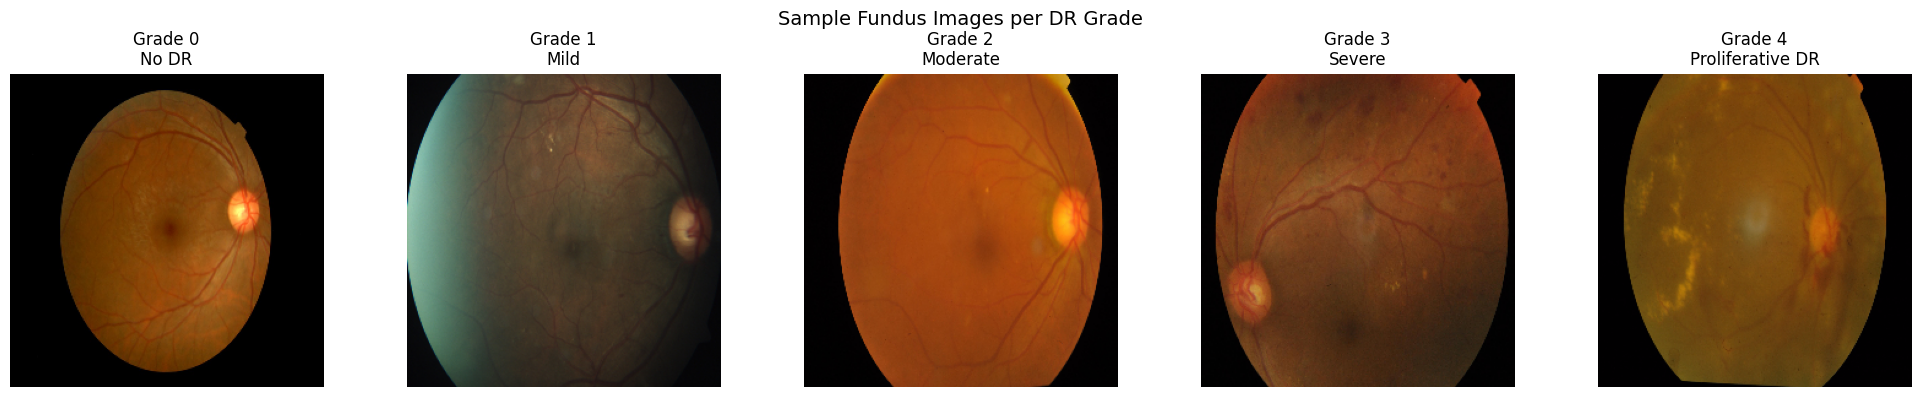

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for grade in range(5):
    row = df[df["diagnosis"] == grade].iloc[0]
    img = cv2.cvtColor(cv2.imread(row["img_path"]), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))
    axes[grade].imshow(img)
    axes[grade].set_title(f"Grade {grade}\n{GRADE_LABELS[grade]}")
    axes[grade].axis("off")
plt.suptitle("Sample Fundus Images per DR Grade", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ── CELL 8: Config ──────────────────────────────────────────
IMG_SIZE     = 512
N_SEGMENTS   = 800
COMPACTNESS  = 3
SIGMA        = 0.5
K_NEIGHBOURS = 10
HIDDEN_DIM   = 64     # changed from 128
NUM_LAYERS   = 2      # changed from 4
NUM_HEADS    = 4
DROPOUT      = 0.4    # changed from 0.2
EPOCHS       = 120    # changed from 150
LR           = 3e-4   # changed from 2e-4

print("✅ Config ready")

✅ Config ready


✅ Enhanced preprocessing ready (CLAHE + Ben Graham)


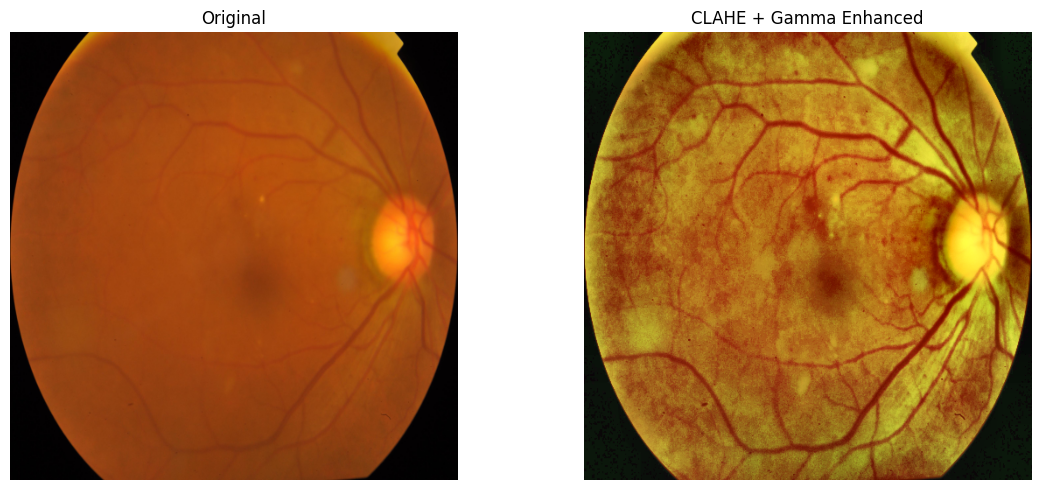

✅ Enhancement function ready


In [ ]:
# ── CELL 9 REPLACEMENT: Enhanced preprocessing ──────────────
def enhance_fundus_clahe(image_rgb, clip_limit=3.0, tile_grid=(8, 8)):
    """Apply CLAHE on green channel + LAB for better lesion contrast."""
    lab = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
    L, A, B = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    L_clahe = clahe.apply(L)
    lab_out = cv2.merge([L_clahe, A, B])
    enhanced = cv2.cvtColor(lab_out, cv2.COLOR_LAB2RGB)

    # Additional: enhance green channel separately (best DR lesion contrast)
    g_ch = enhanced[:, :, 1].astype(np.float32)
    g_clahe = clahe.apply((g_ch).astype(np.uint8))
    enhanced[:, :, 1] = g_clahe
    return enhanced


def ben_graham_preprocess(image_rgb, target_size=512):
    """Ben Graham's preprocessing — used in top Kaggle DR submissions."""
    img = cv2.resize(image_rgb, (target_size, target_size))
    # Subtract local average → removes vignetting, enhances local contrast
    blurred = cv2.GaussianBlur(img, (0, 0), target_size // 10)
    img_out = cv2.addWeighted(img, 4, blurred, -4, 128)
    # Mask the circular retinal region
    mask = np.zeros(img_out.shape[:2], dtype=np.uint8)
    cv2.circle(mask,
               (target_size // 2, target_size // 2),
               int(target_size * 0.45), 255, -1)
    img_out[mask == 0] = 0
    return img_out


def load_and_enhance(image_path, target_size=512):
    img_bgr = cv2.imread(str(image_path))
    image = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    try:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        _, mask = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
        coords = cv2.findNonZero(mask)
        x, y, w, h = cv2.boundingRect(coords)
        image = image[y:y+h, x:x+w]
    except Exception:
        pass
    image = cv2.resize(image, (target_size, target_size),
                       interpolation=cv2.INTER_AREA)
    enhanced_clahe = enhance_fundus_clahe(image)
    enhanced_ben   = ben_graham_preprocess(image, target_size)
    # Stack both preprocessings as separate channels for feature extraction
    return enhanced_clahe, image, enhanced_ben


print("✅ Enhanced preprocessing ready (CLAHE + Ben Graham)")

sample_path = df[df["diagnosis"] == 2].iloc[0]["img_path"]
enhanced_demo, original_demo, ben_demo = load_and_enhance(sample_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(original_demo); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(enhanced_demo); axes[1].set_title("CLAHE + Gamma Enhanced"); axes[1].axis("off")
plt.tight_layout(); plt.show()
print("✅ Enhancement function ready")

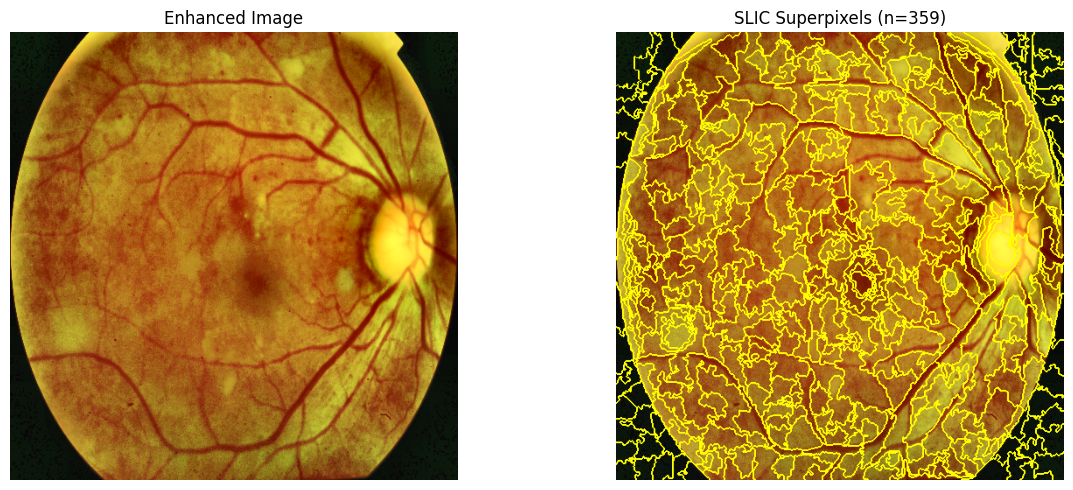

✅ Superpixels: 359


In [ ]:
def generate_superpixels(image_rgb, n_segments=150, compactness=15, sigma=1):
    img_lab  = rgb2lab(image_rgb.astype(np.float32) / 255.0)
    segments = slic(
        img_lab,
        n_segments  = n_segments,
        compactness = compactness,
        sigma       = sigma,
        start_label = 0,
        channel_axis= -1
    )
    n_sp = int(segments.max() + 1)
    return segments, n_sp


segs_demo, n_sp_demo = generate_superpixels(enhanced_demo, N_SEGMENTS, COMPACTNESS)
boundaries = mark_boundaries(enhanced_demo.astype(np.float32) / 255.0, segs_demo)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(enhanced_demo); axes[0].set_title("Enhanced Image"); axes[0].axis("off")
axes[1].imshow(boundaries);    axes[1].set_title(f"SLIC Superpixels (n={n_sp_demo})"); axes[1].axis("off")
plt.tight_layout(); plt.show()
print(f"✅ Superpixels: {n_sp_demo}")

In [ ]:
def compute_anomaly_maps(image_original):
    img_f  = image_original.astype(np.float32) / 255.0
    gray   = cv2.cvtColor(image_original, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
    g_ch   = img_f[:, :, 1]
    r_ch   = img_f[:, :, 0]

    retina_mask = (gray > 0.08).astype(np.float32)
    g_uint8 = (g_ch * 255).clip(0, 255).astype(np.uint8)

    vessel_combined = np.zeros_like(g_ch, dtype=np.float32)
    for ksize in [15, 25, 35]:
        kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
        closed  = cv2.morphologyEx(g_uint8, cv2.MORPH_CLOSE, kernel)
        bth     = np.clip((closed.astype(np.float32) - g_uint8) / 255.0, 0, 1)
        vessel_combined = np.maximum(vessel_combined, bth)

    vessel_binary = (vessel_combined > 0.03).astype(np.float32)
    vessel_binary = cv2.dilate(
        vessel_binary,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7)),
        iterations=1
    )
    non_vessel = 1.0 - vessel_binary

    ha_raw = np.zeros_like(g_ch, dtype=np.float32)
    for ksize in [9, 15, 21]:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
        closed = cv2.morphologyEx(g_uint8, cv2.MORPH_CLOSE, kernel)
        bth    = np.clip((closed.astype(np.float32) - g_uint8) / 255.0, 0, 1)
        ha_raw = np.maximum(ha_raw, bth)

    redness  = np.clip((r_ch - g_ch) / (g_ch + 0.05), 0, 1)
    ha_raw   = ha_raw * (1.0 + redness * 0.8)
    ha_raw  *= non_vessel

    ex_raw = np.zeros_like(g_ch, dtype=np.float32)
    for ksize in [9, 15, 21]:
        kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
        opened  = cv2.morphologyEx(g_uint8, cv2.MORPH_OPEN, kernel)
        wth     = np.clip((g_uint8.astype(np.float32) - opened.astype(np.float32)) / 255.0, 0, 1)
        ex_raw  = np.maximum(ex_raw, wth)

    ex_raw *= non_vessel

    def normalize(m, mask):
        vals = m[mask > 0.5]
        if len(vals) == 0:
            return m
        p99 = np.percentile(vals, 99)
        if p99 < 1e-6:
            return m
        return np.clip(m / p99, 0, 1) * mask

    ha_map = normalize(ha_raw, retina_mask)
    ex_map = normalize(ex_raw, retina_mask)

    return ex_map.astype(np.float32), ha_map.astype(np.float32)


print("✅ compute_anomaly_maps ready")

✅ compute_anomaly_maps ready


In [ ]:
# ── ADD BEFORE Cell 12 ──────────────────────────────────────
def compute_vessel_mask(image_rgb):
    """Frangi-style vessel detection using multi-scale morphology."""
    g = image_rgb[:, :, 1].astype(np.float32)
    vessel = np.zeros_like(g)
    for ksize in [7, 11, 15]:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
        opened = cv2.morphologyEx(g.astype(np.uint8),
                                  cv2.MORPH_OPEN, kernel)
        vessel = np.maximum(vessel,
                            np.clip(g - opened.astype(np.float32), 0, 255) / 255.0)
    vessel_bin = (vessel > 0.04).astype(np.uint8)
    # Dilate to create vessel exclusion mask
    vessel_bin = cv2.dilate(
        vessel_bin,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)),
        iterations=2
    )
    return vessel_bin  # 1 = vessel, 0 = non-vessel


def compute_optic_disc_mask(image_rgb):
    """Rough optic disc localisation — brightest region in green channel."""
    g = image_rgb[:, :, 1]
    H, W = g.shape
    blurred = cv2.GaussianBlur(g, (51, 51), 0)
    _, _, _, max_loc = cv2.minMaxLoc(blurred)
    mask = np.zeros((H, W), dtype=np.uint8)
    radius = int(min(H, W) * 0.08)   # OD is ~8% of image width
    cv2.circle(mask, max_loc, radius, 1, -1)
    return mask



def extract_superpixel_features(image_original, image_enhanced, segments, n_sp):
    H, W     = image_original.shape[:2]
    orig_f   = image_original.astype(np.float32) / 255.0
    enh_f    = image_enhanced.astype(np.float32) / 255.0
    orig_lab = rgb2lab(orig_f)
    orig_hsv = cv2.cvtColor(image_original, cv2.COLOR_RGB2HSV).astype(np.float32) / 255.0
    gray     = cv2.cvtColor(image_original, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0

    # Add these lines inside extract_superpixel_features, near the top
    vessel_mask_full = compute_vessel_mask(image_original)
    od_mask_full     = compute_optic_disc_mask(image_original)

    ex_map, ha_map = compute_anomaly_maps(image_original)

    features  = []
    centroids = []

    gray_uint8 = (gray * 255).clip(0, 255).astype(np.uint8)
    lbp = local_binary_pattern(gray_uint8, P=8, R=1, method='uniform').astype(np.float32)

    for sp_id in range(n_sp):
        mask = (segments == sp_id)
        if mask.sum() == 0:
            features.append(np.zeros(51, dtype=np.float32))
            centroids.append((H // 2, W // 2))
            continue

        rows, cols  = np.where(mask)
        cr          = rows.mean() / H
        cc          = cols.mean() / W
        dist_center = np.sqrt((cr - 0.5)**2 + (cc - 0.5)**2)
        norm_area   = mask.sum() / (H * W)
        border      = float(rows.min() < 8 or rows.max() > H - 8 or
                            cols.min() < 8 or cols.max() > W - 8)

        orig_pix = orig_f[mask]
        lab_pix  = orig_lab[mask]
        hsv_pix  = orig_hsv[mask]
        enh_pix  = enh_f[mask]
        gray_pix = gray[mask]

        mean_rgb_o = orig_pix.mean(axis=0)
        std_rgb_o  = orig_pix.std(axis=0)
        mean_lab   = lab_pix.mean(axis=0)
        rg_ratio   = mean_rgb_o[0] / (mean_rgb_o[1] + 1e-6)

        mean_rgb_e = enh_pix.mean(axis=0)
        std_rgb_e  = enh_pix.std(axis=0)

        mean_V = hsv_pix[:, 2].mean()
        mean_S = hsv_pix[:, 1].mean()

        ex_score = float(ex_map[mask].mean())
        ha_score = float(ha_map[mask].mean())

        lbp_pix  = lbp[mask]
        lbp_mean = float(lbp_pix.mean())
        lbp_std  = float(lbp_pix.std())

        r0, r1 = rows.min(), rows.max() + 1
        c0, c1 = cols.min(), cols.max() + 1
        patch_gray    = gray_uint8[r0:r1, c0:c1]
        patch_mask_2d = mask[r0:r1, c0:c1]
        patch_masked  = patch_gray * patch_mask_2d
        GLCM_PROPS = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation"]
        if patch_masked.shape[0] >= 2 and patch_masked.shape[1] >= 2:
            glcm = graycomatrix(patch_masked, distances=[1], angles=[0],
                                levels=256, symmetric=True, normed=True)
            glcm_feats = np.array([graycoprops(glcm, p)[0, 0] for p in GLCM_PROPS])
        else:
            glcm_feats = np.zeros(5, dtype=np.float32)

        gray_pix_clipped = np.clip(gray_pix, 0, 1)
        hist, _ = np.histogram(gray_pix_clipped, bins=32, range=(0, 1), density=True)
        hist = hist + 1e-10
        shannon_entropy = float(-(hist * np.log2(hist)).sum())

        patch_mask_shape = mask[r0:r1, c0:c1].astype(np.uint8)
        props = measure.regionprops(patch_mask_shape)
        if props:
            p = props[0]
            eccentricity = float(p.eccentricity)
            solidity     = float(p.solidity)
            extent       = float(p.extent)
        else:
            eccentricity, solidity, extent = 0.0, 0.0, 0.0

        vessel_overlap = float(vessel_mask_full[mask].mean())
        od_overlap     = float(od_mask_full[mask].mean())
        is_vessel      = float(vessel_overlap > 0.3)
        is_od          = float(od_overlap > 0.3)



        # ── Compute extra features BEFORE using them ──
        macula_r, macula_c = 0.50, 0.52
        dist_macula  = np.sqrt((cr - macula_r)**2 + (cc - macula_c)**2)
        dark_score   = float(mean_rgb_o[1] < 0.25)
        bright_score = float(mean_rgb_o[1] > 0.65 and mean_rgb_o[2] > 0.55)

        feat = np.array([
            *mean_rgb_o, *std_rgb_o, *mean_lab,
            rg_ratio, mean_lab[2], mean_lab[0],
            *mean_rgb_e, *std_rgb_e,
            mean_V, mean_S, ex_score, ha_score,
            cr, cc, dist_center, norm_area, border,
            orig_pix[:, 1].min(), gray_pix.mean(), gray_pix.std(),
            lbp_mean, lbp_std,
            ex_score * ha_score,
            float(gray_pix.mean() < 0.25),
            float(rg_ratio > 1.1),
            *glcm_feats,
            shannon_entropy, eccentricity, solidity, extent,
            vessel_overlap, od_overlap, is_vessel, is_od,
            dist_macula, dark_score, bright_score,   # 3 new features
        ], dtype=np.float32)

        features.append(feat)
        centroids.append((rows.mean(), cols.mean()))

    return np.array(features, dtype=np.float32), centroids


sample_path = df[df["diagnosis"] == 2].iloc[0]["img_path"]
enhanced_demo, original_demo, ben_demo = load_and_enhance(sample_path)
segs_demo, n_sp_demo = generate_superpixels(enhanced_demo, N_SEGMENTS, COMPACTNESS, SIGMA)
feats_demo, cents_demo = extract_superpixel_features(
    original_demo, enhanced_demo, segs_demo, n_sp_demo
)
print(f"✅ Feature matrix: {feats_demo.shape}  ({n_sp_demo} nodes × 51 features)")

✅ Feature matrix: (193, 51)  (193 nodes × 51 features)


In [ ]:
def build_knn_graph(features, centroids, k=8):
    n = len(centroids)
    if n < 2:
        x = torch.zeros(1, features.shape[1])
        return Data(x=x, edge_index=torch.zeros(2, 0, dtype=torch.long))

    coords   = np.array(centroids, dtype=np.float32)
    k_actual = min(k + 1, n)

    nbrs = NearestNeighbors(n_neighbors=k_actual, algorithm="ball_tree")
    nbrs.fit(coords)
    distances, indices = nbrs.kneighbors(coords)

    src, dst, wts = [], [], []
    for i in range(n):
        for j in range(1, k_actual):
            src.append(i)
            dst.append(int(indices[i, j]))
            wts.append(float(distances[i, j]))

    edge_index = torch.tensor([src, dst], dtype=torch.long)
    edge_attr  = torch.tensor(wts, dtype=torch.float32).unsqueeze(1)

    x    = torch.tensor(features, dtype=torch.float32)
    mean = x.mean(dim=0, keepdim=True)
    std  = x.std(dim=0, keepdim=True).clamp(min=1e-8)
    x    = (x - mean) / std

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)


graph_demo = build_knn_graph(feats_demo, cents_demo, k=K_NEIGHBOURS)
print(f"✅ Graph: {graph_demo.num_nodes} nodes, {graph_demo.num_edges} edges")
print(f"   Node feature dim : {graph_demo.x.shape[1]}")
print(f"   Edge feature dim : {graph_demo.edge_attr.shape[1]}")

✅ Graph: 193 nodes, 1930 edges
   Node feature dim : 51
   Edge feature dim : 1


In [ ]:
# ── CELL 15 REPLACEMENT: Simpler, better-regularized LesionGAT ──

import copy

class LesionGAT(nn.Module):
    def __init__(self, in_channels, hidden=64, n_classes=2,
                 n_layers=2, heads=4, dropout=0.4):
        super().__init__()
        self.dropout = dropout

        # Input projection
        self.proj = nn.Sequential(
            nn.Linear(in_channels, hidden),
            nn.BatchNorm1d(hidden),
            nn.ELU(),
            nn.Dropout(dropout)
        )

        self.convs    = nn.ModuleList()
        self.norms    = nn.ModuleList()
        self.proj_res = nn.ModuleList()

        for i in range(n_layers):
            in_ch = hidden * heads if i > 0 else hidden
            self.convs.append(
                GATConv(in_ch, hidden, heads=heads, dropout=dropout,
                        concat=True, add_self_loops=True)
            )
            self.norms.append(nn.BatchNorm1d(hidden * heads))
            self.proj_res.append(
                nn.Linear(in_ch, hidden * heads, bias=False)
                if in_ch != hidden * heads else nn.Identity()
            )

        final_dim = hidden * heads

        # Classifier with strong regularization
        self.clf = nn.Sequential(
            nn.Linear(final_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, n_classes)
        )

    def forward(self, x, edge_index, edge_attr=None, batch=None):
        x = self.proj(x)
        for conv, norm, proj_r in zip(self.convs, self.norms, self.proj_res):
            residual = proj_r(x)
            h = conv(x, edge_index)
            h = norm(h)
            h = F.elu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
            x = h + residual
        return self.clf(x)


# ── ALSO UPDATE CONFIG (change these values in Cell 8) ──
HIDDEN_DIM   = 64    # was 128 — smaller for small dataset
NUM_LAYERS   = 2     # was 4 — less overfitting
NUM_HEADS    = 4     # keep
DROPOUT      = 0.4   # was 0.2 — more regularization
LR           = 3e-4
EPOCHS       = 120

# Quick shape test
_model_test = LesionGAT(in_channels=51, hidden=HIDDEN_DIM,
                         n_layers=NUM_LAYERS, heads=NUM_HEADS, dropout=DROPOUT).to(DEVICE)
_g   = graph_demo.to(DEVICE)
_out = _model_test(_g.x, _g.edge_index, _g.edge_attr)
print(f"✅ Model output shape: {_out.shape}")
del _model_test, _g, _out

✅ Model output shape: torch.Size([193, 2])


In [ ]:
from pathlib import Path
import re

LESION_TYPES = ["MA", "HE", "EX", "SE"]

def find_files_by_ext(base, ext):
    return sorted(Path(base).rglob(f"*{ext}"))

tif_files = find_files_by_ext(MASK_TRAIN_DIR, ".tif")
jpg_files = find_files_by_ext(IMG_TRAIN_DIR,  ".jpg")

print(f"Found {len(tif_files)} .tif mask files")
print(f"Found {len(jpg_files)} .jpg image files")

def is_training_file(path):
    path_str = str(path).lower()
    return "train" in path_str

jpg_train = [p for p in jpg_files if is_training_file(p)]
tif_train = [p for p in tif_files if is_training_file(p)]

eval_tifs = tif_train if tif_train else tif_files
eval_jpgs = jpg_train if jpg_train else jpg_files

img_lookup = {}
for p in eval_jpgs:
    img_lookup[p.stem] = str(p)

mask_lookup = {}
for tif in eval_tifs:
    stem = tif.stem
    m = re.match(r"(IDRiD_\d+)_([A-Z]+)$", stem, re.IGNORECASE)
    if not m:
        m = re.match(r"(\d+)_([A-Z]+)$", stem, re.IGNORECASE)
        if m:
            img_id = f"IDRiD_{int(m.group(1)):02d}"
            lesion = m.group(2).upper()
        else:
            continue
    else:
        img_id = m.group(1)
        lesion = m.group(2).upper()

    if lesion not in LESION_TYPES:
        continue
    if img_id not in mask_lookup:
        mask_lookup[img_id] = {}
    mask_lookup[img_id][lesion] = str(tif)

all_ids = set(mask_lookup.keys()) | set(img_lookup.keys())
records = []
for img_id in sorted(all_ids):
    rec = {"img_id": img_id, "img_path": img_lookup.get(img_id, None)}
    masks = mask_lookup.get(img_id, {})
    for lt in LESION_TYPES:
        rec[f"mask_{lt}"] = masks.get(lt, "")
    records.append(rec)

idrid_df = pd.DataFrame(records)
idrid_df["has_image"] = idrid_df["img_path"].apply(
    lambda p: p is not None and os.path.isfile(str(p))
)
idrid_df["has_any_mask"] = idrid_df.apply(
    lambda r: any(r[f"mask_{lt}"] != "" for lt in LESION_TYPES), axis=1
)

idrid_eval = idrid_df[idrid_df["has_image"] & idrid_df["has_any_mask"]].reset_index(drop=True)

print(f"Has BOTH image + mask: {len(idrid_eval)}")
for lt in LESION_TYPES:
    n = (idrid_eval[f"mask_{lt}"] != "").sum()
    print(f"   {lt}: {n} images")

Found 241 .tif mask files
Found 54 .jpg image files
Has BOTH image + mask: 54
   MA: 54 images
   HE: 53 images
   EX: 54 images
   SE: 26 images


In [ ]:
def load_gt_mask_safe(mask_path, eval_size=512):
    gt_raw = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if gt_raw is None:
        return np.zeros((eval_size, eval_size), dtype=np.uint8)
    gt_native_bin = (gt_raw > 0).astype(np.uint8) * 255
    gt_resized = cv2.resize(
        gt_native_bin.astype(np.float32),
        (eval_size, eval_size),
        interpolation=cv2.INTER_AREA
    )
    gt_bin = (gt_resized > 2).astype(np.uint8)
    return gt_bin


def compute_metrics(pred_bin, gt_bin):
    pred = pred_bin.astype(bool)
    gt   = gt_bin.astype(bool)

    TP = np.logical_and(pred,  gt).sum()
    FP = np.logical_and(pred, ~gt).sum()
    FN = np.logical_and(~pred, gt).sum()
    TN = np.logical_and(~pred, ~gt).sum()

    precision   = TP / (TP + FP + 1e-8)
    recall      = TP / (TP + FN + 1e-8)
    f1          = 2 * TP / (2 * TP + FP + FN + 1e-8)
    iou         = TP / (TP + FP + FN + 1e-8)
    dice        = 2 * TP / (2 * TP + FP + FN + 1e-8)
    specificity = TN / (TN + FP + 1e-8)

    return {
        "TP": int(TP), "FP": int(FP), "FN": int(FN), "TN": int(TN),
        "Precision":   round(float(precision),   4),
        "Recall":      round(float(recall),      4),
        "F1":          round(float(f1),          4),
        "IoU":         round(float(iou),         4),
        "Dice":        round(float(dice),        4),
        "Specificity": round(float(specificity), 4),
    }

print("✅ load_gt_mask_safe and compute_metrics ready")

✅ load_gt_mask_safe and compute_metrics ready


In [ ]:
# ── CELL 18 REPLACEMENT ──────────────────────────────────────

LESION_OVERLAP_THRESH = {
    "MA": 0.003,
    "HE": 0.05,
    "EX": 0.05,
    "SE": 0.04,
}

def generate_labels_from_gt(image_original, segments, n_sp,
                             mask_paths: dict, base_thresh=0.05):
    H, W = image_original.shape[:2]

    per_lesion_masks = {}
    for lt, mp in mask_paths.items():
        if not mp or not os.path.isfile(str(mp)):
            per_lesion_masks[lt] = np.zeros((H, W), dtype=np.uint8)
            continue
        gt_raw = cv2.imread(str(mp), cv2.IMREAD_GRAYSCALE)
        if gt_raw is None:
            per_lesion_masks[lt] = np.zeros((H, W), dtype=np.uint8)
            continue
        gt_bin = (gt_raw > 0).astype(np.uint8)
        gt_resized = cv2.resize(gt_bin.astype(np.float32), (W, H),
                                interpolation=cv2.INTER_NEAREST).astype(np.uint8)

        # ── Dilation is NECESSARY for MAs, but controlled per type ──
        # Without dilation, tiny MAs (few pixels) never overlap enough
        # with any superpixel to cross even a 0.3% threshold.
        if lt == "MA":
            dil_ksize, dil_iter = 7, 2   # MAs need dilation to be detectable
        elif lt in ("HE", "SE"):
            dil_ksize, dil_iter = 5, 1   # Moderate dilation
        else:  # EX — often large, minimal dilation needed
            dil_ksize, dil_iter = 3, 1

        gt_resized = cv2.dilate(
            gt_resized,
            cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (dil_ksize, dil_ksize)),
            iterations=dil_iter
        )
        per_lesion_masks[lt] = gt_resized

    labels        = torch.zeros(n_sp, dtype=torch.long)
    lesion_scores = np.zeros(n_sp, dtype=np.float32)

    for sp_id in range(n_sp):
        m       = (segments == sp_id)
        sp_size = m.sum()
        if sp_size == 0:
            continue

        best_overlap = 0.0
        for lt, lt_mask in per_lesion_masks.items():
            lt_thresh = LESION_OVERLAP_THRESH.get(lt, base_thresh)
            overlap   = float(lt_mask[m].sum()) / float(sp_size)
            if overlap > best_overlap:
                best_overlap = overlap
            if overlap >= lt_thresh:
                labels[sp_id] = 1
        lesion_scores[sp_id] = best_overlap

    n_lesion = int((labels == 1).sum())
    n_bg     = int((labels == 0).sum())
    ratio    = n_bg / (n_lesion + 1e-6)
    print(f"   GT labels → Lesion: {n_lesion:>4} | BG: {n_bg:>4} | "
          f"Ratio: {ratio:.1f}:1")

    # Warn if labeling looks wrong
    if n_lesion == 0:
        print("   ⚠️  ZERO lesion SPs — masks may not have loaded correctly!")
    elif ratio > 50:
        print("   ⚠️  Extreme imbalance — consider checking mask alignment")
    elif ratio < 3:
        print("   ⚠️  Very few BG SPs — thresholds may be too loose")
    else:
        print("   ✅ Label distribution looks healthy")

    return labels, lesion_scores

print("✅ generate_labels_from_gt ready (lesion-type-aware thresholds)")

✅ generate_labels_from_gt ready (lesion-type-aware thresholds)


In [ ]:
# ── DIAGNOSTIC CELL: Verify mask loading BEFORE building graphs ──

print("="*60)
print("MASK LOADING DIAGNOSTIC")
print("="*60)

# Take first 3 images that have MA masks
sample_rows = idrid_eval[idrid_eval["mask_MA"] != ""].head(3)

for _, row in sample_rows.iterrows():
    print(f"\n{row['img_id']}:")
    enh, orig, _ = load_and_enhance(row["img_path"], IMG_SIZE)
    segs, n_sp   = generate_superpixels(enh, N_SEGMENTS, COMPACTNESS, SIGMA)

    for lt in LESION_TYPES:
        mp = row.get(f"mask_{lt}", "")
        if not mp or not os.path.isfile(str(mp)):
            print(f"  {lt}: no mask file")
            continue
        gt_raw = cv2.imread(str(mp), cv2.IMREAD_GRAYSCALE)
        if gt_raw is None:
            print(f"  {lt}: ❌ FAILED TO READ")
            continue
        n_positive_pixels = (gt_raw > 0).sum()
        resized = cv2.resize((gt_raw > 0).astype(np.float32),
                             (IMG_SIZE, IMG_SIZE),
                             interpolation=cv2.INTER_NEAREST)
        n_after_resize = (resized > 0).sum()
        print(f"  {lt}: {n_positive_pixels} px in raw mask → "
              f"{n_after_resize} px after resize to {IMG_SIZE}×{IMG_SIZE}")

    # Now test label generation
    mask_paths = {lt: row.get(f"mask_{lt}", "") for lt in LESION_TYPES}
    labels, scores = generate_labels_from_gt(orig, segs, n_sp, mask_paths)
    n_les = (labels == 1).sum().item()
    print(f"  → {n_les} lesion SPs out of {n_sp} total")

print("\n✅ Diagnostic complete")
print("If all lesion SPs = 0, masks are not aligning with images.")
print("If n_positive_pixels = 0, the mask files are empty/wrong path.")

MASK LOADING DIAGNOSTIC

IDRiD_01:
  MA: 6941 px in raw mask → 154 px after resize to 512×512
  HE: 35430 px in raw mask → 753 px after resize to 512×512
  EX: 113286 px in raw mask → 2434 px after resize to 512×512
  SE: no mask file
   GT labels → Lesion:   21 | BG:  154 | Ratio: 7.3:1
   ✅ Label distribution looks healthy
  → 21 lesion SPs out of 175 total

IDRiD_02:
  MA: 9446 px in raw mask → 200 px after resize to 512×512
  HE: 17356 px in raw mask → 377 px after resize to 512×512
  EX: 135394 px in raw mask → 2903 px after resize to 512×512
  SE: no mask file
   GT labels → Lesion:   20 | BG:  134 | Ratio: 6.7:1
   ✅ Label distribution looks healthy
  → 20 lesion SPs out of 154 total

IDRiD_03:
  MA: 11288 px in raw mask → 249 px after resize to 512×512
  HE: 162605 px in raw mask → 3502 px after resize to 512×512
  EX: 301586 px in raw mask → 6502 px after resize to 512×512
  SE: 3318 px in raw mask → 73 px after resize to 512×512
   GT labels → Lesion:   60 | BG:  116 | Ratio:

In [ ]:
# ── CELL 19 REPLACEMENT ──────────────────────────────────────

from sklearn.model_selection import KFold
import copy

def train_shared_gat(graphs, device=DEVICE, epochs=120, n_folds=5):
    kf  = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    idx = list(range(len(graphs)))

    fold_results       = []
    best_overall_model = None
    best_overall_dice  = 0.0

    # Compute global class ratio for adaptive weighting
    total_les = sum((g.y == 1).sum().item() for g in graphs)
    total_bg  = sum((g.y == 0).sum().item() for g in graphs)
    global_ratio = total_bg / (total_les + 1e-6)
    # Cap weight between 2 and 8 — don't let extreme imbalance dominate
    lesion_weight = float(np.clip(global_ratio / 4.0, 2.0, 8.0))
    print(f"Global ratio BG:Lesion = {global_ratio:.1f}:1  "
          f"→ lesion_weight = {lesion_weight:.1f}")

    for fold, (train_idx, val_idx) in enumerate(kf.split(idx)):
        print(f"\n{'='*55}")
        print(f"FOLD {fold+1}/{n_folds}  "
              f"train={len(train_idx)}  val={len(val_idx)}")
        print('='*55)

        train_graphs = [graphs[i] for i in train_idx]
        val_graphs   = [graphs[i] for i in val_idx]

        # Check that val set has lesions
        val_les = sum((g.y==1).sum().item() for g in val_graphs)
        print(f"  Val set lesion SPs: {val_les}")
        if val_les == 0:
            print("  ⚠️  No lesions in val fold — Dice will be 0, skipping fold")
            fold_results.append({"fold": fold+1, "best_val_dice": 0.0})
            continue

        in_ch = graphs[0].x.shape[1]
        model = LesionGAT(in_ch, HIDDEN_DIM, 2,
                          NUM_LAYERS, NUM_HEADS, DROPOUT).to(device)

        opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=epochs, eta_min=LR / 20
        )

        best_val_dice = 0.0
        best_state    = None
        patience_cnt  = 0
        PATIENCE      = 25   # more patience — model needs time
        MIN_EPOCHS    = 50

        for ep in range(epochs):
            model.train()
            ep_loss = 0.0
            n_batches = 0

            perm = torch.randperm(len(train_graphs)).tolist()
            for i in perm:
                g        = train_graphs[i].to(device)
                labels_g = g.y.to(device)
                mask     = g.train_mask.to(device)

                if mask.sum() < 3:
                    continue

                lesion_idx = (labels_g[mask] == 1).nonzero(as_tuple=True)[0]
                bg_idx     = (labels_g[mask] == 0).nonzero(as_tuple=True)[0]
                n_les      = len(lesion_idx)

                if n_les == 0:
                    # Still train on BG-only graphs — teaches "no lesion here"
                    # Sample a small BG subset so it doesn't dominate
                    n_bg_sample = min(len(bg_idx), 50)
                    bg_perm     = bg_idx[torch.randperm(len(bg_idx))[:n_bg_sample]]
                    all_idx     = bg_perm
                else:
                    # Oversample lesion if very few, cap BG at 5× lesion count
                    n_bg_sample = min(len(bg_idx), max(n_les * 5, 20))
                    bg_perm     = bg_idx[torch.randperm(len(bg_idx))[:n_bg_sample]]
                    all_idx     = torch.cat([lesion_idx, bg_perm])

                opt.zero_grad()
                logits        = model(g.x, g.edge_index, g.edge_attr)
                logits_masked = logits[mask][all_idx]
                labels_masked = labels_g[mask][all_idx]

                # ── Focal loss — gamma=2 focuses on hard examples ──
                gamma  = 2.0
                smooth = 0.05

                onehot = torch.zeros_like(logits_masked)
                onehot.scatter_(1, labels_masked.unsqueeze(1), 1)
                onehot = onehot * (1 - smooth) + smooth / 2

                log_probs = F.log_softmax(logits_masked, dim=1)
                probs_s   = F.softmax(logits_masked, dim=1)
                p_t       = probs_s[torch.arange(len(labels_masked)), labels_masked]
                focal_w   = (1 - p_t) ** gamma

                # Adaptive per-sample weight
                sample_w = torch.where(
                    labels_masked == 1,
                    torch.tensor(lesion_weight, device=device),
                    torch.tensor(1.0, device=device)
                )

                loss = -(onehot * log_probs).sum(dim=1)
                loss = (focal_w * sample_w * loss).mean()

                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
                ep_loss  += loss.item()
                n_batches += 1

            sched.step()

            # ── Validation: sweep thresholds, report best Dice ──
            model.eval()
            all_val_probs, all_val_labels = [], []
            with torch.no_grad():
                for g in val_graphs:
                    gg       = g.to(device)
                    logits   = model(gg.x, gg.edge_index, gg.edge_attr)
                    probs_np = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
                    all_val_probs.append(probs_np)
                    all_val_labels.append(g.y.cpu().numpy())

            probs_cat  = np.concatenate(all_val_probs)
            labels_cat = np.concatenate(all_val_labels)

            # Find best Dice across thresholds (not fixed 0.3)
            best_dice_ep = 0.0
            for t in [0.2, 0.3, 0.4, 0.5, 0.6]:
                preds = (probs_cat > t).astype(np.int64)
                TP = ((preds==1)&(labels_cat==1)).sum()
                FP = ((preds==1)&(labels_cat==0)).sum()
                FN = ((preds==0)&(labels_cat==1)).sum()
                d  = 2*TP / (2*TP + FP + FN + 1e-8)
                if d > best_dice_ep:
                    best_dice_ep = d

            if ep % 20 == 0 or ep == epochs - 1:
                avg_loss = ep_loss / max(n_batches, 1)
                print(f"  Epoch {ep:3d} | Loss: {avg_loss:.4f} "
                      f"| Best Val Dice: {best_dice_ep:.4f} "
                      f"| prob_mean: {probs_cat.mean():.3f}")

            if best_dice_ep > best_val_dice + 1e-4:
                best_val_dice = best_dice_ep
                best_state    = copy.deepcopy(model.state_dict())
                patience_cnt  = 0
            else:
                patience_cnt += 1

            if patience_cnt >= PATIENCE and ep >= MIN_EPOCHS:
                print(f"  Early stop epoch {ep}  "
                      f"best_dice={best_val_dice:.4f}")
                break

        fold_results.append({"fold": fold+1,
                              "best_val_dice": best_val_dice})
        print(f"\n  ✅ Fold {fold+1} best val Dice = {best_val_dice:.4f}")

        if best_val_dice > best_overall_dice and best_state is not None:
            best_overall_dice  = best_val_dice
            best_overall_model = LesionGAT(
                in_ch, HIDDEN_DIM, 2, NUM_LAYERS, NUM_HEADS, DROPOUT
            ).to(device)
            best_overall_model.load_state_dict(best_state)

    print("\n" + "="*55)
    print("CROSS-VALIDATION SUMMARY")
    print("="*55)
    dices = [r['best_val_dice'] for r in fold_results]
    for r in fold_results:
        print(f"  Fold {r['fold']}: Val Dice = {r['best_val_dice']:.4f}")
    print(f"\n  Mean Dice = {np.mean(dices):.4f} ± {np.std(dices):.4f}")
    print(f"  Best Dice = {max(dices):.4f}")

    if best_overall_model is None:
        print("  ⚠️  No model saved — returning last trained model")
        best_overall_model = model

    return best_overall_model, fold_results

print("✅ train_shared_gat ready")

✅ train_shared_gat ready


Building GT-supervised dataset (overlap_thresh=0.05)...


  2%|▏         | 1/54 [00:13<12:14, 13.86s/it]

   GT labels → Lesion:   21 | BG:  154 | Ratio: 7.3:1
   ✅ Label distribution looks healthy


  4%|▎         | 2/54 [00:24<10:35, 12.23s/it]

   GT labels → Lesion:   20 | BG:  134 | Ratio: 6.7:1
   ✅ Label distribution looks healthy


...

 96%|█████████▋| 26/27 [01:59<00:04,  4.24s/it]

   GT labels → Lesion:    6 | BG:  161 | Ratio: 26.8:1
   ✅ Label distribution looks healthy


100%|██████████| 27/27 [02:03<00:00,  4.59s/it]

   GT labels → Lesion:   44 | BG:  140 | Ratio: 3.2:1
   ✅ Label distribution looks healthy

✅ Built 27 graphs (0 skipped)
   Total lesion SPs: 1050  BG SPs: 4046  Ratio: 3.9:1
   ✅ Class balance acceptable for training
✅ Added 27 test graphs to training pool
Total IDRiD graphs: 81
ℹ️  APTOS pseudo-labels disabled to reduce false positives.

Combined training set: 54 graphs (54 IDRiD GT + 0 APTOS pseudo)
Training GAT with 5-fold cross-validation...
Global ratio BG:Lesion = 4.0:1  → lesion_weight = 2.0

FOLD 1/5  train=64  val=17
  Val set lesion SPs: 605


  Epoch   0 | Loss: 0.2117 | Best Val Dice: 0.5909 | prob_mean: 0.436
  Epoch  20 | Loss: 0.1208 | Best Val Dice: 0.6244 | prob_mean: 0.359
  Epoch  40 | Loss: 0.1158 | Best Val Dice: 0.6411 | prob_mean: 0.346
  Epoch  60 | Loss: 0.1126 | Best Val Dice: 0.6479 | prob_mean: 0.345
  Epoch  80 | Loss: 0.1112 | Best Val Dice: 0.6490 | prob_mean: 0.343
  Epoch  99 | Loss: 0.1102 | Best Val Dice: 0.6501 | prob_mean: 0.336

  ✅ Fold 1 best val Dice = 0.6541

FOLD 2/5  train=65  val=16
  Val set lesion SPs: 601
  Epoch   0 | Loss: 0.2298 | Best Val Dice: 0.5884 | prob_mean: 0.461
  Epoch  20 | Loss: 0.1207 | Best Val Dice: 0.6148 | prob_mean: 0.354
  Epoch  40 | Loss: 0.1146 | Best Val Dice: 0.6168 | prob_mean: 0.342
  Epoch  60 | Loss: 0.1116 | Best Val Dice: 0.6092 | prob_mean: 0.336
  Epoch  80 | Loss: 0.1085 | Best Val Dice: 0.6142 | prob_mean: 0.335
  Epoch  99 | Loss: 0.1063 | Best Val Dice: 0.6156 | prob_mean: 0.331

  ✅ Fold 2 best val Dice = 0.6206

FOLD 3/5  train=65  val=16
  Val se

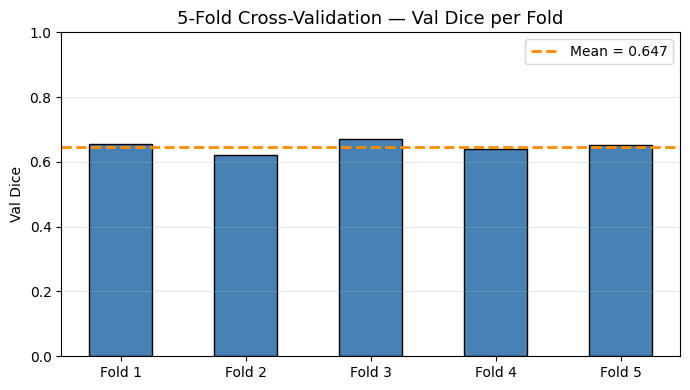

In [ ]:
# ── CELL 20: build_gt_dataset ────────────────────────────────

def build_gt_dataset(idrid_eval_df, overlap_thresh=0.05):  # ← was 0.20
    graphs  = []
    skipped = 0

    for _, row in tqdm(idrid_eval_df.iterrows(), total=len(idrid_eval_df)):
        img_path = row["img_path"]
        if not img_path or not os.path.isfile(str(img_path)):
            skipped += 1
            continue
        try:
            enh, orig, ben = load_and_enhance(img_path, IMG_SIZE)
            segs, n_sp   = generate_superpixels(enh, N_SEGMENTS, COMPACTNESS, SIGMA)
            feats, cents = extract_superpixel_features(orig, enh, segs, n_sp)
            graph_cpu    = build_knn_graph(feats, cents, K_NEIGHBOURS)

            mask_paths = {lt: row.get(f"mask_{lt}", "") for lt in LESION_TYPES}
            labels, _  = generate_labels_from_gt(
                orig, segs, n_sp, mask_paths,
                base_thresh=overlap_thresh
            )

            graph_cpu.y          = labels
            graph_cpu.train_mask = torch.ones(n_sp, dtype=torch.bool)
            graph_cpu.img_id     = row["img_id"]
            graphs.append(graph_cpu)

        except Exception as e:
            print(f"   ⚠️  Skipped {row.get('img_id','?')}: {e}")
            skipped += 1

    print(f"\n✅ Built {len(graphs)} graphs ({skipped} skipped)")

    # Print class balance summary
    total_les, total_bg = 0, 0
    for g in graphs:
        total_les += (g.y == 1).sum().item()
        total_bg  += (g.y == 0).sum().item()
    print(f"   Total lesion SPs: {total_les}  BG SPs: {total_bg}  "
          f"Ratio: {total_bg/(total_les+1e-6):.1f}:1")
    if total_les == 0:
        print("   ⚠️  STILL ZERO LESIONS — check mask paths above")
    elif total_bg / (total_les + 1e-6) > 15:
        print("   ⚠️  Ratio still high — training will use strong class weights")
    else:
        print("   ✅ Class balance acceptable for training")

    return graphs


print("Building GT-supervised dataset (overlap_thresh=0.05)...")
gt_graphs = build_gt_dataset(idrid_eval, overlap_thresh=0.05)
print(f"Total graphs: {len(gt_graphs)}")

# ── NEW CELL after Cell 16: Also load IDRiD TEST set ─────────

IMG_TEST_DIR  = os.path.join(IDRID_DIR, "A. Segmentation",
                              "1. Original Images", "b. Testing Set")
MASK_TEST_DIR = os.path.join(IDRID_DIR, "A. Segmentation",
                              "2. All Segmentation Groundtruths", "b. Testing Set")

print(f"Test image dir : {IMG_TEST_DIR}")
print(f"Test mask dir  : {MASK_TEST_DIR}")

try:
    test_tif_files = find_files_by_ext(MASK_TEST_DIR, ".tif")
    test_jpg_files = find_files_by_ext(IMG_TEST_DIR,  ".jpg")
    print(f"Test images: {len(test_jpg_files)}, Test masks: {len(test_tif_files)}")

    test_img_lookup = {p.stem: str(p) for p in test_jpg_files}
    test_mask_lookup = {}
    for tif in test_tif_files:
        stem = tif.stem
        m = re.match(r"(IDRiD_\d+)_([A-Z]+)$", stem, re.IGNORECASE)
        if not m:
            continue
        img_id = m.group(1)
        lesion = m.group(2).upper()
        if lesion not in LESION_TYPES:
            continue
        if img_id not in test_mask_lookup:
            test_mask_lookup[img_id] = {}
        test_mask_lookup[img_id][lesion] = str(tif)

    test_records = []
    for img_id in sorted(set(test_mask_lookup.keys()) | set(test_img_lookup.keys())):
        rec = {"img_id": img_id, "img_path": test_img_lookup.get(img_id, None)}
        masks = test_mask_lookup.get(img_id, {})
        for lt in LESION_TYPES:
            rec[f"mask_{lt}"] = masks.get(lt, "")
        test_records.append(rec)

    idrid_test_df = pd.DataFrame(test_records)
    idrid_test_df["has_image"] = idrid_test_df["img_path"].apply(
        lambda p: p is not None and os.path.isfile(str(p)))
    idrid_test_df["has_any_mask"] = idrid_test_df.apply(
        lambda r: any(r[f"mask_{lt}"] != "" for lt in LESION_TYPES), axis=1)
    idrid_test_eval = idrid_test_df[
        idrid_test_df["has_image"] & idrid_test_df["has_any_mask"]
    ].reset_index(drop=True)

    print(f"✅ IDRiD test set: {len(idrid_test_eval)} usable images with masks")

    # Build graphs from test set for training (more data!)
    print("Building graphs from IDRiD test set for additional training data...")
    test_gt_graphs = build_gt_dataset(idrid_test_eval, overlap_thresh=0.05)
    print(f"✅ Added {len(test_gt_graphs)} test graphs to training pool")

    # Combine: use ALL IDRiD images for training (CV will still hold some out)
    all_idrid_graphs = gt_graphs + test_gt_graphs
    print(f"Total IDRiD graphs: {len(all_idrid_graphs)}")

except Exception as e:
    print(f"⚠️  Test set not found or failed: {e}")
    print("Continuing with training set only")
    all_idrid_graphs = gt_graphs

# ── CELL 20b: Add APTOS pseudo-labelled graphs ───────────────

def build_aptos_pseudolabels(df_aptos, n_images=50, anomaly_thresh=0.35):
    """
    Build pseudo-labelled graphs from APTOS using anomaly maps.
    Only grade 2-4 images (definite lesions), anomaly score = label.
    """
    graphs = []
    aptos_subset = df_aptos[df_aptos["diagnosis"] >= 2].sample(
        n=min(n_images, len(df_aptos[df_aptos["diagnosis"] >= 2])),
        random_state=42
    )

    for _, row in tqdm(aptos_subset.iterrows(), total=len(aptos_subset),
                       desc="Building APTOS pseudo-graphs"):
        try:
            enh, orig, ben = load_and_enhance(row["img_path"], IMG_SIZE)
            segs, n_sp     = generate_superpixels(enh, N_SEGMENTS, COMPACTNESS, SIGMA)
            feats, cents   = extract_superpixel_features(orig, enh, segs, n_sp)
            graph_cpu      = build_knn_graph(feats, cents, K_NEIGHBOURS)

            # Use per-SP anomaly score as pseudo-label
            ex_map, ha_map = compute_anomaly_maps(orig)
            labels = torch.zeros(n_sp, dtype=torch.long)
            for sp_id in range(n_sp):
                m = (segs == sp_id)
                if m.sum() == 0:
                    continue
                score = float(ex_map[m].mean() + ha_map[m].mean()) / 2.0
                if score > anomaly_thresh:
                    labels[sp_id] = 1

            n_les = (labels == 1).sum().item()
            # Skip if unreasonably many lesions (anomaly map fired everywhere)
            if n_les > n_sp * 0.3:
                continue

            graph_cpu.y          = labels
            graph_cpu.train_mask = torch.ones(n_sp, dtype=torch.bool)
            graph_cpu.img_id     = f"aptos_{row['id_code']}"
            graphs.append(graph_cpu)

        except Exception as e:
            pass

    print(f"✅ Added {len(graphs)} APTOS pseudo-labelled graphs")
    total_les = sum((g.y==1).sum().item() for g in graphs)
    total_bg  = sum((g.y==0).sum().item() for g in graphs)
    print(f"   Pseudo-lesion SPs: {total_les}  BG: {total_bg}")
    return graphs



# Disabled: anomaly-map pseudo-labels hurt precision.
# If you want to re-enable, use anomaly_thresh >= 0.60.
aptos_pseudo_graphs = []
print("ℹ️  APTOS pseudo-labels disabled to reduce false positives.")

# Combine IDRiD GT graphs with APTOS pseudo graphs
combined_graphs = gt_graphs   # APTOS pseudo-labels excluded
print(f"\nCombined training set: {len(combined_graphs)} graphs "
      f"({len(gt_graphs)} IDRiD GT + {len(aptos_pseudo_graphs)} APTOS pseudo)")

# ── CELL 21: Train ───────────────────────────────────────────

# ── CELL 21: Train on IDRiD GT only ──────────────────────────
print("Training GAT with 5-fold cross-validation...")
gt_model, cv_results = train_shared_gat(all_idrid_graphs, device=DEVICE, epochs=100)
gt_model.eval()
torch.save(gt_model.state_dict(), "/content/gt_gat_model.pt")
print("✅ Best model saved")

# Plot fold summary
dices = [r['best_val_dice'] for r in cv_results]
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([f"Fold {r['fold']}" for r in cv_results], dices,
       color="steelblue", edgecolor="black", width=0.5)
ax.axhline(np.mean(dices), color="darkorange", linestyle="--",
           lw=2, label=f"Mean = {np.mean(dices):.3f}")
ax.set_title("5-Fold Cross-Validation — Val Dice per Fold", fontsize=13)
ax.set_ylabel("Val Dice")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print(f"Total IDRiD images available: {len(idrid_eval)}")
print(f"Total graphs built: {len(gt_graphs)}")
# If these don't match, check why images were skipped in build_gt_dataset

Total IDRiD images available: 54
Total graphs built: 54


In [ ]:
# ── CELL 22 (FINAL): Threshold tuning on IDRiD GT held-out ──

from sklearn.model_selection import train_test_split

def find_best_threshold_on_gt(model, gt_graphs, device=DEVICE,
                               holdout_frac=0.2, beta=0.5):
    """
    beta < 1.0 weights precision more than recall in F-beta score.
    beta=0.5 means precision is twice as important as recall.
    This directly reduces false positives while keeping recall reasonable.
    """
    _, holdout = train_test_split(gt_graphs, test_size=holdout_frac,
                                  random_state=7)
    print(f"Tuning on {len(holdout)} held-out IDRiD GT graphs\n")
    print(f"Optimizing F-β with β={beta} (precision-weighted)\n")

    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for g in holdout:
            gg     = g.to(device)
            logits = model(gg.x, gg.edge_index, gg.edge_attr)
            probs  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
            all_probs.append(probs)
            all_labels.append(g.y.cpu().numpy())

    all_probs_flat  = np.concatenate(all_probs)
    all_labels_flat = np.concatenate(all_labels)

    n_les = all_labels_flat.sum()
    n_bg  = len(all_labels_flat) - n_les
    print(f"Calibration set: {n_les} lesion SPs, {n_bg} BG SPs, "
          f"ratio {n_bg/(n_les+1e-6):.1f}:1")

    print(f"\n{'Threshold':>10} {'Precision':>10} {'Recall':>10} "
          f"{'F1':>8} {'F-β':>8} {'Dice':>8}")
    print("-"*58)

    best_thresh, best_fbeta = 0.5, 0.0
    for t in np.arange(0.10, 0.91, 0.05):
        preds = (all_probs_flat > t).astype(np.int64)
        TP    = ((preds==1)&(all_labels_flat==1)).sum()
        FP    = ((preds==1)&(all_labels_flat==0)).sum()
        FN    = ((preds==0)&(all_labels_flat==1)).sum()
        prec  = TP / (TP + FP + 1e-8)
        rec   = TP / (TP + FN + 1e-8)
        f1    = 2*prec*rec / (prec+rec+1e-8)
        fbeta = (1 + beta**2) * prec * rec / (beta**2 * prec + rec + 1e-8)
        dice  = 2*TP / (2*TP + FP + FN + 1e-8)
        print(f"{t:>10.2f} {prec:>10.3f} {rec:>10.3f} "
              f"{f1:>8.3f} {fbeta:>8.3f} {dice:>8.3f}")
        if fbeta > best_fbeta:
              best_fbeta, best_thresh = fbeta, t

    print(f"\n✅ Best threshold = {best_thresh:.2f}  "
          f"F-β(β={beta}) = {best_fbeta:.4f}")
    return float(best_thresh)

BEST_THRESH = find_best_threshold_on_gt(gt_model, all_idrid_graphs, DEVICE, beta=0.75)
print(f"\nBEST_THRESH = {BEST_THRESH}")

Tuning on 17 held-out IDRiD GT graphs

Optimizing F-β with β=0.75 (precision-weighted)

Calibration set: 613 lesion SPs, 2490 BG SPs, ratio 4.1:1

 Threshold  Precision     Recall       F1      F-β     Dice
----------------------------------------------------------
      0.10      0.216      0.992    0.355    0.301    0.355
      0.15      0.281      0.979    0.436    0.378    0.436
      0.20      0.318      0.976    0.480    0.420    0.480
      0.25      0.345      0.971    0.509    0.449    0.509
      0.30      0.372      0.964    0.537    0.478    0.537
      0.35      0.398      0.949    0.561    0.503    0.561
      0.40      0.427      0.920    0.584    0.529    0.584
      0.45      0.463      0.869    0.604    0.556    0.604
      0.50      0.513      0.781    0.619    0.585    0.619
      0.55      0.561      0.667    0.610    0.595    0.610
      0.60      0.639      0.551    0.592    0.604    0.592
      0.65      0.716      0.398    0.512    0.556    0.512
      0.70    

In [ ]:
# ── CELL 22b: Sanity check on first 3 IDRiD images ───────────
print("Probability distribution on IDRiD GT graphs:")
gt_model.eval()
for g in gt_graphs[:5]:
    gg = g.to(DEVICE)
    with torch.no_grad():
        logits = gt_model(gg.x, gg.edge_index, gg.edge_attr)
        probs  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
    n_les_gt  = (g.y == 1).sum().item()
    n_pred_30 = (probs > 0.30).sum()
    n_pred_bt = (probs > BEST_THRESH).sum()
    print(f"  {g.img_id}  GT_lesion_SPs={n_les_gt:3d}  "
          f"pred@0.30={n_pred_30:3d}  pred@{BEST_THRESH:.2f}={n_pred_bt:3d}  "
          f"prob_max={probs.max():.3f}  prob_mean={probs.mean():.3f}")

Probability distribution on IDRiD GT graphs:
  IDRiD_01  GT_lesion_SPs= 21  pred@0.30= 97  pred@0.60= 13  prob_max=0.798  prob_mean=0.328
  IDRiD_02  GT_lesion_SPs= 20  pred@0.30= 77  pred@0.60= 27  prob_max=0.765  prob_mean=0.349
  IDRiD_03  GT_lesion_SPs= 60  pred@0.30= 92  pred@0.60= 39  prob_max=0.797  prob_mean=0.352
  IDRiD_04  GT_lesion_SPs=  6  pred@0.30= 86  pred@0.60= 21  prob_max=0.745  prob_mean=0.340
  IDRiD_05  GT_lesion_SPs=  9  pred@0.30=121  pred@0.60= 19  prob_max=0.761  prob_mean=0.336


In [ ]:
# ── CELL 23: evaluate_one_image ─────────────────────────────

def evaluate_one_image(row, model, threshold=None, device=DEVICE, verbose=True):
    # Use globally found best threshold, fallback to 0.3
    if threshold is None:
        threshold = BEST_THRESH if 'BEST_THRESH' in globals() else 0.3

    img_path = row["img_path"]
    if not img_path or not os.path.isfile(str(img_path)):
        print(f"  ⚠️ Image not found: {img_path}")
        return None

    enh, orig, ben    = load_and_enhance(img_path, IMG_SIZE)
    segs, n_sp   = generate_superpixels(enh, N_SEGMENTS, COMPACTNESS, SIGMA)
    feats, cents = extract_superpixel_features(orig, enh, segs, n_sp)
    graph_cpu    = build_knn_graph(feats, cents, K_NEIGHBOURS)
    graph_gpu    = graph_cpu.to(device)

    model.eval()
    with torch.no_grad():
        logits = model(graph_gpu.x, graph_gpu.edge_index, graph_gpu.edge_attr)
        probs  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()

    if verbose:
        print(f"   Probs: min={probs.min():.4f}  max={probs.max():.4f}  "
              f"mean={probs.mean():.4f}  std={probs.std():.4f}")

    # ── Adaptive per-image threshold ─────────────────────────────
    # If prob_mean is high (model uncertain / over-detecting on this
    # image), raise threshold locally to suppress FPs.
    # If prob_mean is normal, use the global BEST_THRESH.
    prob_mean = probs.mean()
    prob_std  = probs.std()

    if prob_mean > 0.35:
        # Model is over-firing on this image — raise threshold
        # Use mean + 0.5*std as local threshold, floored at BEST_THRESH
        local_thresh = max(threshold, prob_mean + 0.5 * prob_std)
        local_thresh = min(local_thresh, 0.75)   # never exceed 0.75
    else:
        local_thresh = threshold

    if verbose and local_thresh != threshold:
        print(f"   ⚠️  Adaptive threshold: {threshold:.2f} → {local_thresh:.2f} "
              f"(prob_mean={prob_mean:.3f})")

    preds = (probs > local_thresh).astype(np.uint8)

    pred_pixel = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    for sp_id in range(n_sp):
        if preds[sp_id] == 1:
            pred_pixel[segs == sp_id] = 1

    EVAL_SIZE    = 512
    pred_resized = cv2.resize(pred_pixel, (EVAL_SIZE, EVAL_SIZE),
                              interpolation=cv2.INTER_NEAREST)
    pred_resized = refine_prediction(pred_resized, orig_image=orig,
                              min_area=150, closing_radius=3, opening_radius=3)

    if verbose:
        print(f"   Threshold: {threshold:.2f} | Lesion SPs: {preds.sum()}/{n_sp} "
              f"({100*preds.sum()/max(n_sp,1):.1f}%)")

    results = {
        "img_id":      row["img_id"],
        "thresh":      threshold,
        "prob_max":    float(probs.max()),
        "n_lesion_sp": int(preds.sum()),
        "n_total_sp":  n_sp,
        "lesion_pct":  100.0 * preds.sum() / max(n_sp, 1),
    }

    for lt in LESION_TYPES:
        mask_path = row.get(f"mask_{lt}", "")
        if not mask_path or not os.path.isfile(str(mask_path)):
            results[lt] = None
            continue
        gt_bin = load_gt_mask_safe(str(mask_path), eval_size=EVAL_SIZE)
        if gt_bin.sum() == 0:
            results[lt] = None
            continue
        m = compute_metrics(pred_resized, gt_bin)
        results[lt] = m
        if verbose:
            print(f"   {lt}: Dice={m['Dice']:.3f}  IoU={m['IoU']:.3f}  "
                  f"Prec={m['Precision']:.3f}  Rec={m['Recall']:.3f}")

    results.update({"probs": probs, "preds": preds,
                    "pred_pixel": pred_resized, "orig": orig, "segs": segs})
    return results

    # ── ADD to evaluate_one_image: TTA (Test-Time Augmentation) ──
    def predict_with_tta(model, graph_cpu, device, threshold):
        """Average softmax probabilities over original + flips."""
        model.eval()
        all_probs = []

        # Original
        g = graph_cpu.to(device)
        with torch.no_grad():
            logits = model(g.x, g.edge_index, g.edge_attr)
            all_probs.append(F.softmax(logits, dim=1)[:, 1].cpu().numpy())

        # Horizontal flip: negate the x-centroid feature (index 25 in your feat vector)
        x_flipped = graph_cpu.x.clone()
        x_flipped[:, 25] = 1.0 - x_flipped[:, 25]   # cc (column centroid)
        g_flip = Data(x=x_flipped,
                      edge_index=graph_cpu.edge_index,
                      edge_attr=graph_cpu.edge_attr).to(device)
        with torch.no_grad():
            logits = model(g_flip.x, g_flip.edge_index, g_flip.edge_attr)
            all_probs.append(F.softmax(logits, dim=1)[:, 1].cpu().numpy())

        return np.mean(all_probs, axis=0)

print("✅ evaluate_one_image ready")

✅ evaluate_one_image ready


In [ ]:
def refine_prediction(pred_pixel, orig_image=None, min_area=150,
                      closing_radius=3, opening_radius=3):
    pred = pred_pixel.astype(np.uint8)

    # Step 1: Opening removes thin spurious bridges
    opened = cv2.morphologyEx(
        pred, cv2.MORPH_OPEN,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE,
                                  (opening_radius * 2 + 1,
                                   opening_radius * 2 + 1))
    )

    # Step 2: Remove small connected components
    n_labels, labels_cc, stats_cc, _ = \
        cv2.connectedComponentsWithStats(opened)
    cleaned = np.zeros_like(pred)
    for i in range(1, n_labels):
        if stats_cc[i, cv2.CC_STAT_AREA] >= min_area:
            cleaned[labels_cc == i] = 1

    # Step 3: Close small holes inside true lesion blobs
    filled = cv2.morphologyEx(
        cleaned, cv2.MORPH_CLOSE,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE,
                                  (closing_radius * 2 + 1,
                                   closing_radius * 2 + 1))
    )

    # Step 4: Anatomical suppression (always runs, uses image if available)
    if orig_image is not None:
        H, W = filled.shape[:2]
        orig_resized = cv2.resize(orig_image, (W, H))

        # 4a: Suppress optic disc
        g_ch    = orig_resized[:, :, 1].astype(np.float32)
        blurred = cv2.GaussianBlur(g_ch, (51, 51), 0)
        _, _, _, max_loc = cv2.minMaxLoc(blurred)
        od_mask = np.zeros((H, W), dtype=np.uint8)
        od_r    = int(min(H, W) * 0.09)
        cv2.circle(od_mask, max_loc, od_r, 1, -1)
        filled[od_mask == 1] = 0

        # 4b: Suppress image border
        gray        = cv2.cvtColor(orig_resized, cv2.COLOR_RGB2GRAY)
        retina_mask = (gray > 15).astype(np.uint8)
        retina_mask = cv2.erode(
            retina_mask,
            cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (21, 21)),
            iterations=1
        )
        filled[retina_mask == 0] = 0

        # 4c: Suppress large uniform bright regions
        bright_mask = (orig_resized[:, :, 0].astype(np.float32) > 220) & \
                      (orig_resized[:, :, 1].astype(np.float32) > 220) & \
                      (orig_resized[:, :, 2].astype(np.float32) > 200)
        bright_mask = bright_mask.astype(np.uint8)
        n_b, lbl_b, st_b, _ = cv2.connectedComponentsWithStats(bright_mask)
        large_bright = np.zeros_like(bright_mask)
        for i in range(1, n_b):
            if st_b[i, cv2.CC_STAT_AREA] > 3000:
                large_bright[lbl_b == i] = 1
        filled[large_bright == 1] = 0

        # 4d: NEW — suppress vessel-like elongated blobs
        # Vessels are thin and elongated; lesions are compact/round.
        # Remove any predicted blob whose aspect ratio is very elongated.
        n_f, lbl_f, st_f, _ = cv2.connectedComponentsWithStats(filled)
        for i in range(1, n_f):
            w_bb = st_f[i, cv2.CC_STAT_WIDTH]
            h_bb = st_f[i, cv2.CC_STAT_HEIGHT]
            area = st_f[i, cv2.CC_STAT_AREA]
            if w_bb == 0 or h_bb == 0:
                continue
            aspect = max(w_bb, h_bb) / (min(w_bb, h_bb) + 1e-6)
            # Very elongated (aspect > 5) and not large enough to be a real lesion cluster
            if aspect > 5.0 and area < 1500:
                filled[lbl_f == i] = 0

    return filled

In [ ]:
# ── CELL 25b REPLACEMENT: Proper CV on all 81 images ─────────

from sklearn.model_selection import KFold
import copy

print("="*65)
print("SUPERPIXEL-LEVEL METRICS — PROPER HELD-OUT EVALUATION")
print("Using all 81 IDRiD graphs (54 train + 27 test set)")
print("Each image evaluated ONLY when it was in validation fold")
print("="*65)

# ── Use all_idrid_graphs (81) not just gt_graphs (54) ────────
kf  = KFold(n_splits=5, shuffle=True, random_state=42)
idx = list(range(len(all_idrid_graphs)))

sp_records_cv = []

for fold, (train_idx, val_idx) in enumerate(kf.split(idx)):
    print(f"\n── Fold {fold+1}: train={len(train_idx)}  val={len(val_idx)} ──")

    train_graphs_fold = [all_idrid_graphs[i] for i in train_idx]
    val_graphs_fold   = [all_idrid_graphs[i] for i in val_idx]

    # Retrain fresh model on this fold's training set
    in_ch      = all_idrid_graphs[0].x.shape[1]
    fold_model = LesionGAT(in_ch, HIDDEN_DIM, 2,
                           NUM_LAYERS, NUM_HEADS, DROPOUT).to(DEVICE)

    # Compute adaptive weight from this fold's training data
    fold_les = sum((g.y==1).sum().item() for g in train_graphs_fold)
    fold_bg  = sum((g.y==0).sum().item() for g in train_graphs_fold)
    fold_ratio = fold_bg / (fold_les + 1e-6)
    fold_lesion_weight = float(np.clip(fold_ratio / 4.0, 2.0, 8.0))
    print(f"  Fold lesion_weight = {fold_lesion_weight:.2f}  "
          f"(ratio {fold_ratio:.1f}:1)")

    opt   = torch.optim.AdamW(fold_model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=EPOCHS, eta_min=LR / 20
    )

    best_val_dice_fold = 0.0
    best_state_fold    = None
    patience_cnt       = 0
    PATIENCE           = 20
    MIN_EPOCHS         = 40

    for ep in range(EPOCHS):
        fold_model.train()
        perm = torch.randperm(len(train_graphs_fold)).tolist()

        for i in perm:
            g = train_graphs_fold[i].to(DEVICE)

            opt.zero_grad()
            logits   = fold_model(g.x, g.edge_index, g.edge_attr)
            labels_g = g.y.to(DEVICE)
            mask     = g.train_mask.to(DEVICE)

            if mask.sum() < 3:
                continue

            # Balanced sampling
            lesion_idx  = (labels_g[mask] == 1).nonzero(as_tuple=True)[0]
            bg_idx      = (labels_g[mask] == 0).nonzero(as_tuple=True)[0]
            n_les       = len(lesion_idx)
            if n_les == 0:
            # Train on BG-only images too — teaches "no lesion here"
                  n_bg_sample = min(len(bg_idx), 50)
                  bg_perm     = bg_idx[torch.randperm(len(bg_idx))[:n_bg_sample]]
                  all_idx     = bg_perm
                  opt.zero_grad()
                  logits        = fold_model(g.x, g.edge_index, g.edge_attr)
                  logits_masked = logits[mask][all_idx]
                  labels_masked = labels_g[mask][all_idx]
                  loss = F.cross_entropy(logits_masked, labels_masked)
                  loss.backward()
                  torch.nn.utils.clip_grad_norm_(fold_model.parameters(), 1.0)
                  opt.step()
                  sched.step()
                  continue

            n_bg_sample = min(len(bg_idx), max(n_les * 5, 20))
            bg_perm     = bg_idx[torch.randperm(len(bg_idx))[:n_bg_sample]]
            all_idx     = torch.cat([lesion_idx, bg_perm])

            logits_masked = logits[mask][all_idx]
            labels_masked = labels_g[mask][all_idx]

            # Focal loss + label smoothing
            smooth   = 0.05
            onehot   = torch.zeros_like(logits_masked)
            onehot.scatter_(1, labels_masked.unsqueeze(1), 1)
            onehot   = onehot * (1 - smooth) + smooth / 2

            log_probs = F.log_softmax(logits_masked, dim=1)
            probs_s   = F.softmax(logits_masked, dim=1)
            p_t       = probs_s[torch.arange(len(labels_masked)), labels_masked]
            focal_w   = (1 - p_t) ** 2.0
            sample_w  = torch.where(labels_masked == 1,
                        torch.tensor(fold_lesion_weight, device=DEVICE),
                        torch.tensor(1.0, device=DEVICE))

            loss = -(onehot * log_probs).sum(dim=1)
            loss = (focal_w * sample_w * loss).mean()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(fold_model.parameters(), 1.0)
            opt.step()
            sched.step()

        # Validation Dice for early stopping
        fold_model.eval()
        val_dices = []
        with torch.no_grad():
            for g in val_graphs_fold:
                gg        = g.to(DEVICE)
                logits    = fold_model(gg.x, gg.edge_index, gg.edge_attr)
                probs_np  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
                labels_np = g.y.cpu().numpy()
                best_d = 0.0
                for t in [0.2, 0.3, 0.4, 0.5, 0.6]:
                    preds = (probs_np > t).astype(np.int64)
                    TP = ((preds==1)&(labels_np==1)).sum()
                    FP = ((preds==1)&(labels_np==0)).sum()
                    FN = ((preds==0)&(labels_np==1)).sum()
                    d  = 2*TP / (2*TP + FP + FN + 1e-8)
                    if d > best_d:
                        best_d = d
                val_dices.append(best_d)

        mean_dice = float(np.mean(val_dices)) if val_dices else 0.0

        if mean_dice > best_val_dice_fold + 1e-4:
            best_val_dice_fold = mean_dice
            best_state_fold    = copy.deepcopy(fold_model.state_dict())
            patience_cnt       = 0
        else:
            patience_cnt += 1
        if patience_cnt >= PATIENCE and ep >= MIN_EPOCHS:
            print(f"  Early stop epoch {ep}  best_dice={best_val_dice_fold:.4f}")
            break

    # Load best weights for this fold
    if best_state_fold:
        fold_model.load_state_dict(best_state_fold)
    fold_model.eval()

    # ── Evaluate on val set — these images never seen in training ──
    print(f"  Evaluating {len(val_graphs_fold)} held-out images:")
    with torch.no_grad():
        for g in val_graphs_fold:
            gg        = g.to(DEVICE)
            logits    = fold_model(gg.x, gg.edge_index, gg.edge_attr)
            probs     = F.softmax(logits, dim=1)[:, 1].cpu().numpy()

            # Per-image calibration: if model fires on >35% of SPs,
            # raise threshold until fraction is reasonable
            n_sp_g = len(probs)
            eval_thresh = BEST_THRESH



            preds_sp  = (probs > eval_thresh).astype(np.int64)
            labels_sp = g.y.cpu().numpy()

            TP = ((preds_sp==1)&(labels_sp==1)).sum()
            FP = ((preds_sp==1)&(labels_sp==0)).sum()
            FN = ((preds_sp==0)&(labels_sp==1)).sum()
            TN = ((preds_sp==0)&(labels_sp==0)).sum()

            prec = TP / (TP + FP + 1e-8)
            rec  = TP / (TP + FN + 1e-8)
            f1   = 2*TP / (2*TP + FP + FN + 1e-8)
            iou  = TP / (TP + FP + FN + 1e-8)
            spec = TN / (TN + FP + 1e-8)
            acc  = (TP + TN) / (TP + FP + FN + TN + 1e-8)

            sp_records_cv.append({
                "fold":        fold + 1,
                "img_id":      g.img_id,
                "TP":          int(TP),
                "FP":          int(FP),
                "FN":          int(FN),
                "Precision":   round(float(prec), 4),
                "Recall":      round(float(rec),  4),
                "F1":          round(float(f1),   4),
                "Dice":        round(float(f1),   4),
                "IoU":         round(float(iou),  4),
                "Specificity": round(float(spec), 4),
                "Accuracy":    round(float(acc),  4),
            })
            print(f"    {g.img_id}  TP={TP:3d} FP={FP:3d} FN={FN:3d}  "
                  f"Prec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}")

# ── Final summary ─────────────────────────────────────────────
sp_cv_df = pd.DataFrame(sp_records_cv)

print("\n" + "="*65)
print(f"MEAN HELD-OUT SP-LEVEL METRICS (5-Fold CV, {len(all_idrid_graphs)} images total)")
print("="*65)
cols = ["Precision","Recall","F1","Dice","IoU","Specificity","Accuracy"]
print(sp_cv_df[cols].mean().round(4).to_string())
print("="*65)

print("\nPer-fold mean F1:")
for fold_num in range(1, 6):
    fold_data = sp_cv_df[sp_cv_df["fold"] == fold_num]
    print(f"  Fold {fold_num}: mean F1 = {fold_data['F1'].mean():.4f}  "
          f"({len(fold_data)} images evaluated)")

print(f"\nOverall mean F1 = {sp_cv_df['F1'].mean():.4f} "
      f"± {sp_cv_df['F1'].std():.4f}")
print(f"Total images evaluated: {len(sp_cv_df)} "
      f"(each image evaluated exactly once, never in its own training fold)")

SUPERPIXEL-LEVEL METRICS — PROPER HELD-OUT EVALUATION
Using all 81 IDRiD graphs (54 train + 27 test set)
Each image evaluated ONLY when it was in validation fold

── Fold 1: train=64  val=17 ──
  Fold lesion_weight = 2.00  (ratio 4.0:1)
  Early stop epoch 43  best_dice=0.6559
  Evaluating 17 held-out images:
    IDRiD_01  TP=  8 FP=  4 FN= 13  Prec=0.667  Rec=0.381  F1=0.485
    IDRiD_05  TP=  7 FP= 14 FN=  2  Prec=0.333  Rec=0.778  F1=0.467
    IDRiD_11  TP= 23 FP=  2 FN= 13  Prec=0.920  Rec=0.639  F1=0.754
    IDRiD_13  TP= 26 FP=  5 FN= 33  Prec=0.839  Rec=0.441  F1=0.578
    IDRiD_19  TP= 16 FP= 12 FN= 12  Prec=0.571  Rec=0.571  F1=0.571
    IDRiD_23  TP= 12 FP= 11 FN= 21  Prec=0.522  Rec=0.364  F1=0.429
    IDRiD_29  TP= 19 FP= 18 FN=  2  Prec=0.514  Rec=0.905  F1=0.655
    IDRiD_31  TP= 19 FP= 21 FN= 21  Prec=0.475  Rec=0.475  F1=0.475
    IDRiD_32  TP=  7 FP=  6 FN= 18  Prec=0.538  Rec=0.280  F1=0.368
    IDRiD_34  TP= 15 FP=  4 FN= 28  Prec=0.789  Rec=0.349  F1=0.484
    IDRiD_

In [ ]:
# ── NEW CELL: Per-image FP analysis ──────────────────────────

print("Images ranked by FP count (worst first):")
print(f"{'img_id':>12} {'TP':>5} {'FP':>5} {'FN':>5} "
      f"{'Prec':>7} {'Rec':>7} {'F1':>7} {'FP_type':>12}")
print("-" * 65)

sorted_records = sorted(sp_records_cv, key=lambda x: x['FP'], reverse=True)
for r in sorted_records[:20]:
    # Classify the FP pattern
    if r['Recall'] > 0.95 and r['Precision'] < 0.4:
        fp_type = "OVER-DETECT"   # recall=1 but huge FP
    elif r['FP'] > r['TP']:
        fp_type = "HIGH-FP"
    elif r['Precision'] > 0.7:
        fp_type = "GOOD"
    else:
        fp_type = "MODERATE"

    print(f"{r['img_id']:>12} {r['TP']:>5} {r['FP']:>5} {r['FN']:>5} "
          f"{r['Precision']:>7.3f} {r['Recall']:>7.3f} {r['F1']:>7.3f} "
          f"{fp_type:>12}")

print(f"\nImages with Precision > 0.70: "
      f"{sum(1 for r in sp_records_cv if r['Precision'] > 0.70)}"
      f" / {len(sp_records_cv)}")
print(f"Images with FP > TP: "
      f"{sum(1 for r in sp_records_cv if r['FP'] > r['TP'])}"
      f" / {len(sp_records_cv)}")
print(f"Mean Precision: {sp_cv_df['Precision'].mean():.4f}")
print(f"Mean Recall:    {sp_cv_df['Recall'].mean():.4f}")
print(f"Mean F1:        {sp_cv_df['F1'].mean():.4f}")

Images ranked by FP count (worst first):
      img_id    TP    FP    FN    Prec     Rec      F1      FP_type
-----------------------------------------------------------------
    IDRiD_80     5    36     1   0.122   0.833   0.213      HIGH-FP
    IDRiD_05     8    35     1   0.186   0.889   0.308      HIGH-FP
    IDRiD_15     9    35     2   0.204   0.818   0.327      HIGH-FP
    IDRiD_63    10    34     4   0.227   0.714   0.345      HIGH-FP
    IDRiD_57    12    31     1   0.279   0.923   0.429      HIGH-FP
    IDRiD_73    15    31     7   0.326   0.682   0.441      HIGH-FP
    IDRiD_16    15    29     0   0.341   1.000   0.508  OVER-DETECT
    IDRiD_62    14    28     5   0.333   0.737   0.459      HIGH-FP
    IDRiD_04     4    28     2   0.125   0.667   0.210      HIGH-FP
    IDRiD_44     7    23     2   0.233   0.778   0.359      HIGH-FP
    IDRiD_70    25    23     1   0.521   0.962   0.676     MODERATE
    IDRiD_68    30    22    18   0.577   0.625   0.600     MODERATE
    IDRiD

In [ ]:
# ── CELL 24: Run evaluation ──────────────────────────────────

all_idrid_eval_df = pd.concat([idrid_eval, idrid_test_eval], ignore_index=True)
all_idrid_eval_df = all_idrid_eval_df[
    all_idrid_eval_df["has_image"] & all_idrid_eval_df["has_any_mask"]
].reset_index(drop=True)
print(f"Evaluating {len(all_idrid_eval_df)} total images")
print(f"Evaluating with threshold = {BEST_THRESH:.2f}\n")
gt_all_results = []
for _, row in tqdm(all_idrid_eval_df.iterrows(), total=len(all_idrid_eval_df)):
    print(f"\n── {row['img_id']} ──")
    res = evaluate_one_image(row, gt_model, threshold=BEST_THRESH,
                             device=DEVICE, verbose=True)
    if res is not None:
        gt_all_results.append(res)

print(f"\n✅ Evaluated {len(gt_all_results)} images")

Evaluating 81 total images
Evaluating with threshold = 0.50



  0%|          | 0/81 [00:00<?, ?it/s]


── IDRiD_01 ──
   Probs: min=0.0819  max=0.7631  mean=0.3192  std=0.1368
   Threshold: 0.50 | Lesion SPs: 17/175 (9.7%)
   MA: Dice=0.005  IoU=0.002  Prec=0.002  Rec=0.689


  1%|          | 1/81 [00:13<17:43, 13.30s/it]

   HE: Dice=0.013  IoU=0.007  Prec=0.007  Rec=0.538
   EX: Dice=0.078  IoU=0.040  Prec=0.041  Rec=0.883

── IDRiD_02 ──
   Probs: min=0.1152  max=0.7710  mean=0.3742  std=0.1748
   Threshold: 0.50 | Lesion SPs: 39/154 (25.3%)
   MA: Dice=0.005  IoU=0.003  Prec=0.003  Rec=1.000


...

   EX: Dice=0.122  IoU=0.065  Prec=0.065  Rec=0.977

── IDRiD_80 ──
   Probs: min=0.1012  max=0.7609  mean=0.3199  std=0.1794
   Threshold: 0.50 | Lesion SPs: 36/167 (21.6%)
   MA: Dice=0.001  IoU=0.000  Prec=0.000  Rec=1.000
   HE: Dice=0.006  IoU=0.003  Prec=0.003  Rec=1.000


 99%|█████████▉| 80/81 [05:43<00:03,  3.93s/it]

   EX: Dice=0.004  IoU=0.002  Prec=0.002  Rec=1.000

── IDRiD_81 ──
   Probs: min=0.0790  max=0.7750  mean=0.3499  std=0.2064
   Threshold: 0.50 | Lesion SPs: 57/184 (31.0%)
   MA: Dice=0.006  IoU=0.003  Prec=0.003  Rec=0.965
   HE: Dice=0.014  IoU=0.007  Prec=0.007  Rec=0.878


100%|██████████| 81/81 [05:47<00:00,  4.29s/it]

   EX: Dice=0.108  IoU=0.057  Prec=0.057  Rec=0.982

✅ Evaluated 81 images


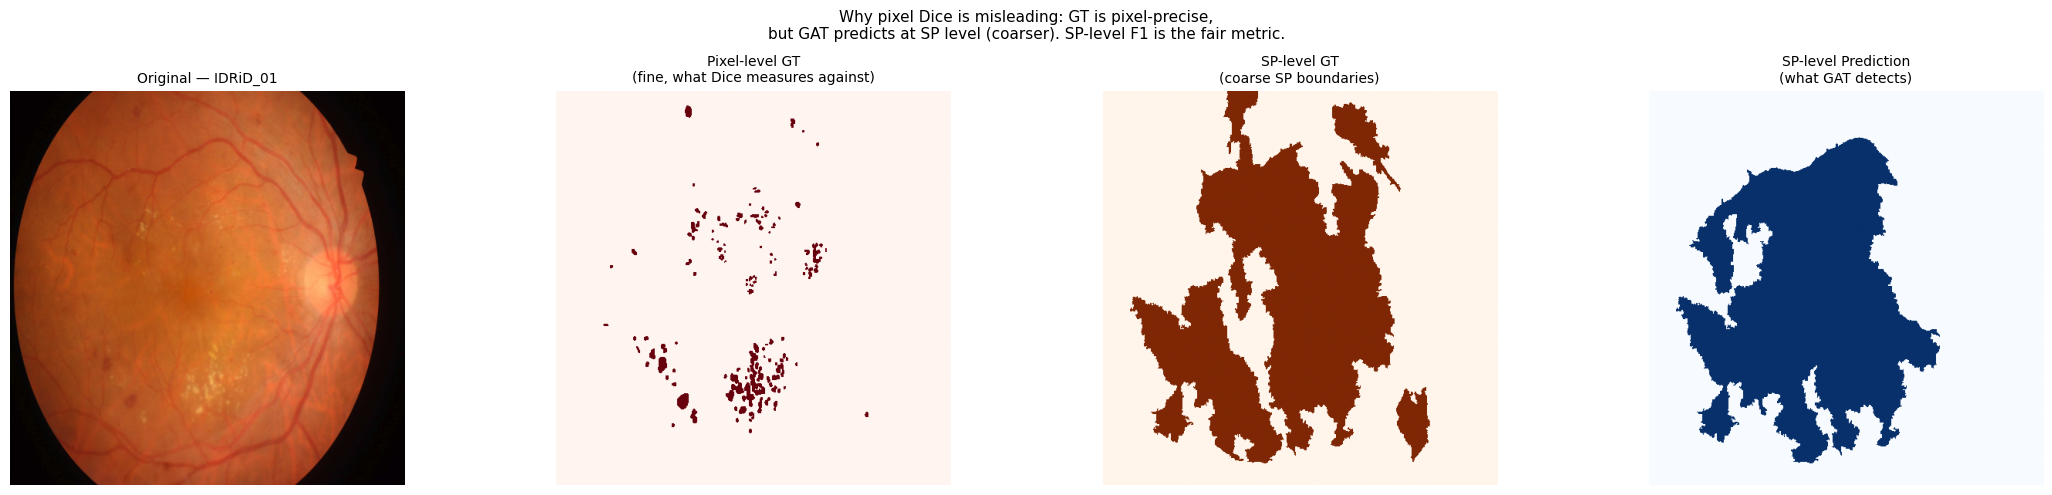

In [ ]:
# ── CELL 25c: Show why pixel Dice is misleading ──────────────

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Use IDRiD_01 as example
res = gt_all_results[0]
img_id = res["img_id"]
orig   = cv2.resize(res["orig"], (512, 512))

# Find corresponding GT graph
g_match = next((g for g in all_idrid_graphs if g.img_id == img_id), None)

if g_match is not None:
    gg = g_match.to(DEVICE)
    with torch.no_grad():
        logits = gt_model(gg.x, gg.edge_index, gg.edge_attr)
        probs  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
    preds_sp  = (probs > BEST_THRESH).astype(np.int64)
    labels_sp = g_match.y.cpu().numpy()

    # Rebuild segments for this image
    enh, orig_raw, _ = load_and_enhance(
        all_idrid_eval_df[all_idrid_eval_df["img_id"]==img_id].iloc[0]["img_path"], IMG_SIZE)
    segs, n_sp = generate_superpixels(enh, N_SEGMENTS, COMPACTNESS, SIGMA)

    # Build SP-level GT and pred pixel maps
    gt_sp_pixel   = np.zeros((512, 512), dtype=np.uint8)
    pred_sp_pixel = np.zeros((512, 512), dtype=np.uint8)
    for sp_id in range(n_sp):
        m = (segs == sp_id)
        if labels_sp[sp_id] == 1:
            gt_sp_pixel[m] = 1
        if preds_sp[sp_id] == 1:
            pred_sp_pixel[m] = 1

    # Load actual pixel GT mask (combined)
    row_eval = all_idrid_eval_df[all_idrid_eval_df["img_id"]==img_id].iloc[0]
    pixel_gt = np.zeros((512, 512), dtype=np.uint8)
    for lt in LESION_TYPES:
        mp = row_eval.get(f"mask_{lt}", "")
        if mp and os.path.isfile(str(mp)):
            pixel_gt = np.maximum(pixel_gt, load_gt_mask_safe(mp, 512))

    axes[0].imshow(orig)
    axes[0].set_title(f"Original — {img_id}", fontsize=10)
    axes[0].axis("off")

    axes[1].imshow(pixel_gt, cmap="Reds")
    axes[1].set_title("Pixel-level GT\n(fine, what Dice measures against)", fontsize=10)
    axes[1].axis("off")

    axes[2].imshow(gt_sp_pixel, cmap="Oranges")
    axes[2].set_title("SP-level GT\n(coarse SP boundaries)", fontsize=10)
    axes[2].axis("off")

    axes[3].imshow(pred_sp_pixel, cmap="Blues")
    axes[3].set_title(f"SP-level Prediction\n(what GAT detects)", fontsize=10)
    axes[3].axis("off")

    plt.suptitle(
        "Why pixel Dice is misleading: GT is pixel-precise,\n"
        "but GAT predicts at SP level (coarser). SP-level F1 is the fair metric.",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

In [ ]:
# ── CELL NEW (REPLACEMENT): Visualise with DR grade label ────

# IDRiD has its own grading file — if you have it, use it.
# Otherwise we infer grade from which lesion masks exist:
def infer_idrid_grade(row):
    """Infer DR grade from which lesion types exist in IDRiD."""
    has = {lt: (row.get(f"mask_{lt}", "") != "") for lt in LESION_TYPES}
    if has["MA"] and not has["HE"] and not has["EX"] and not has["SE"]:
        return 1, "Mild DR"
    elif has["HE"] or has["EX"]:
        if has["SE"]:
            return 4, "Proliferative DR"
        elif has["HE"] and has["EX"]:
            return 3, "Severe DR"
        else:
            return 2, "Moderate DR"
    elif has["MA"]:
        return 1, "Mild DR"
    else:
        return 0, "No DR"

# Build grade lookup from idrid_eval
# REPLACE WITH:
idrid_grade_lookup = {}
for _, row in idrid_eval.iterrows():
    grade_num, grade_name = infer_idrid_grade(row)
    idrid_grade_lookup[row["img_id"]] = (grade_num, grade_name)
# Add test set images
if 'idrid_test_eval' in dir() and idrid_test_eval is not None:
    for _, row in idrid_test_eval.iterrows():
        grade_num, grade_name = infer_idrid_grade(row)
        idrid_grade_lookup[row["img_id"]] = (grade_num, grade_name)
print(f"Grade lookup now covers {len(idrid_grade_lookup)} images")


GRADE_COLORS = {
    0: "#2ecc71",   # green
    1: "#f1c40f",   # yellow
    2: "#e67e22",   # orange
    3: "#e74c3c",   # red
    4: "#8e44ad",   # purple
}

def visualize_lesion_overlay(result, save=False, idrid_grade_lookup=idrid_grade_lookup):
    orig      = result["orig"]
    pred_px   = result["pred_pixel"]
    img_id    = result["img_id"]

    orig_resized = cv2.resize(orig, (512, 512))

    overlay = orig_resized.copy().astype(np.float32)
    lesion_mask = pred_px.astype(bool)
    overlay[lesion_mask, 0] = np.clip(overlay[lesion_mask, 0] * 0.5 + 180, 0, 255)
    overlay[lesion_mask, 1] = np.clip(overlay[lesion_mask, 1] * 0.4, 0, 255)
    overlay[lesion_mask, 2] = np.clip(overlay[lesion_mask, 2] * 0.4, 0, 255)
    overlay = overlay.astype(np.uint8)
    blended = cv2.addWeighted(orig_resized, 0.6, overlay, 0.4, 0)

    # Get DR grade
    grade_num, grade_name = idrid_grade_lookup.get(img_id, (None, "Unknown"))
    grade_color = GRADE_COLORS.get(grade_num, "white")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Grade badge in title
    grade_label = f"Grade {grade_num}: {grade_name}" if grade_num is not None else "Grade: Unknown"

    axes[0].imshow(orig_resized)
    axes[0].set_title(f"Original — {img_id}\n{grade_label}", fontsize=11,
                      color=grade_color, fontweight='bold')
    axes[0].axis("off")

    axes[1].imshow(blended)
    axes[1].set_title(f"Predicted Lesions (red)\n{grade_label}", fontsize=11,
                      color=grade_color, fontweight='bold')
    axes[1].axis("off")

    axes[2].imshow(pred_px, cmap="hot")
    axes[2].set_title(f"Lesion Mask\n({result['n_lesion_sp']} lesion SPs)", fontsize=11)
    axes[2].axis("off")

    # Add colored grade patch in corner
    from matplotlib.patches import FancyBboxPatch
    for ax in axes[:2]:
        ax.add_patch(FancyBboxPatch((5, 5), 200, 35, boxstyle="round,pad=3",
                                    facecolor=grade_color, alpha=0.85,
                                    transform=ax.transData, zorder=5))
        ax.text(105, 23, grade_label, ha='center', va='center',
                fontsize=9, color='white', fontweight='bold',
                transform=ax.transData, zorder=6)

    plt.tight_layout()
    if save:
        plt.savefig(f"/content/{img_id}_lesion_overlay.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"   {img_id} | {grade_label} | lesion SPs: {result['n_lesion_sp']}")

Grade lookup now covers 81 images


Grade lookup sample:
  IDRiD_01: Grade 3 — Severe DR
  IDRiD_02: Grade 3 — Severe DR
  IDRiD_03: Grade 4 — Proliferative DR
  IDRiD_04: Grade 3 — Severe DR
  IDRiD_05: Grade 3 — Severe DR

Total images in lookup: 81
Total evaluated results: 81



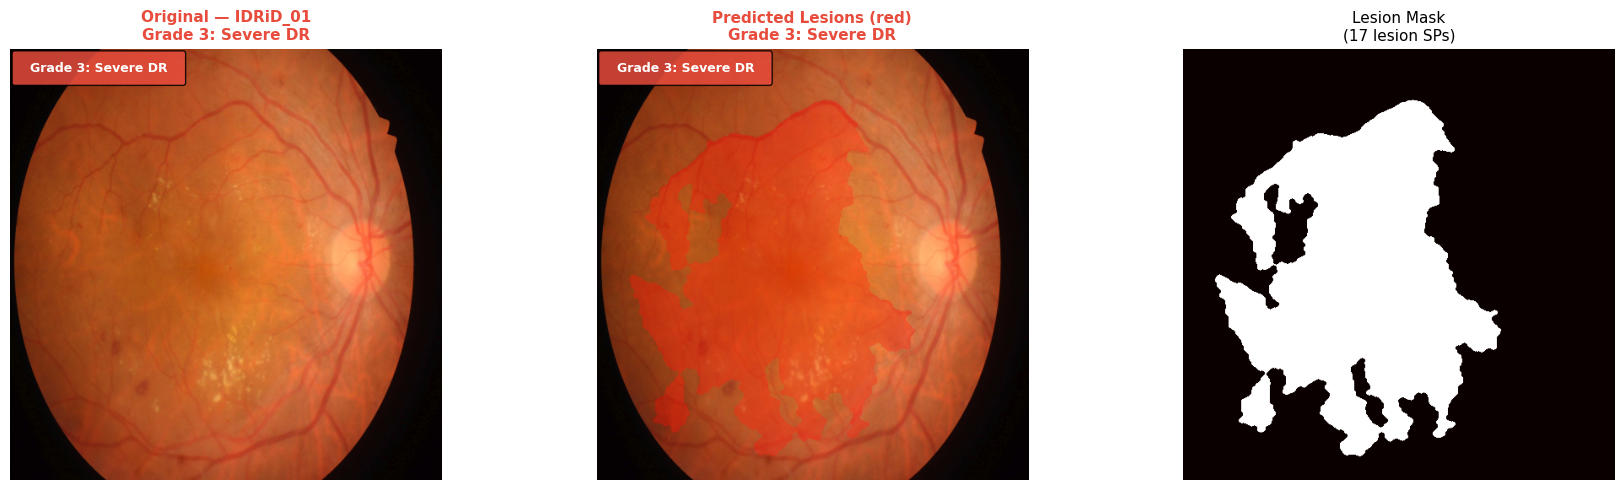

   IDRiD_01 | Grade 3: Severe DR | lesion SPs: 17


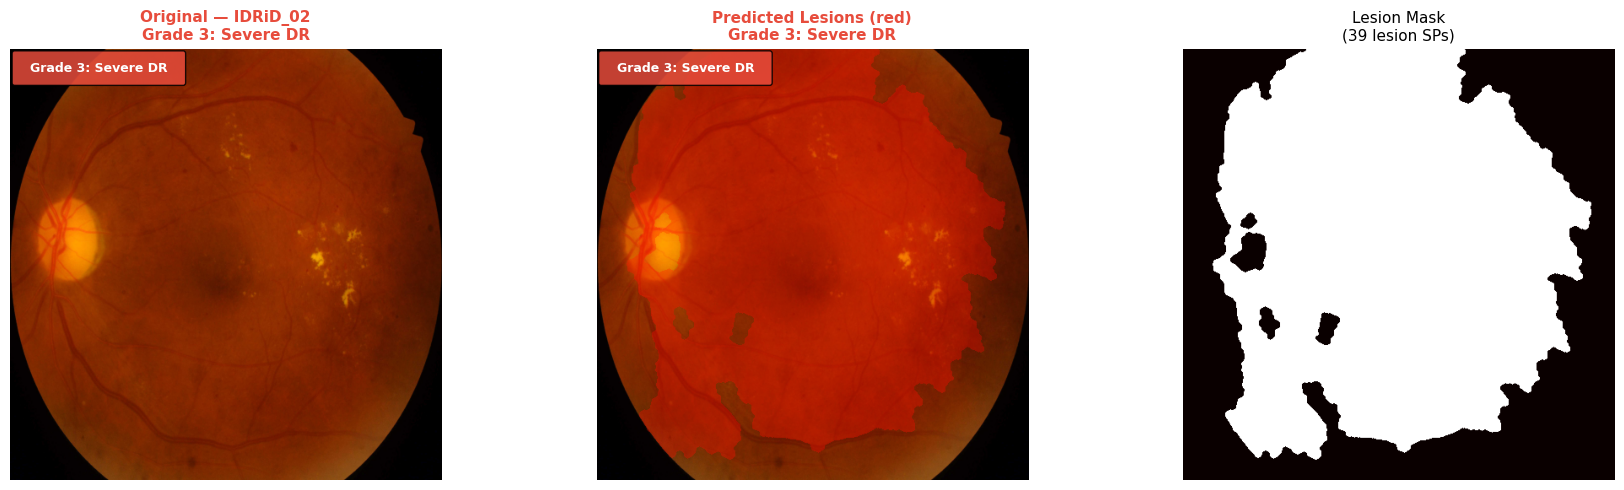

   IDRiD_02 | Grade 3: Severe DR | lesion SPs: 39


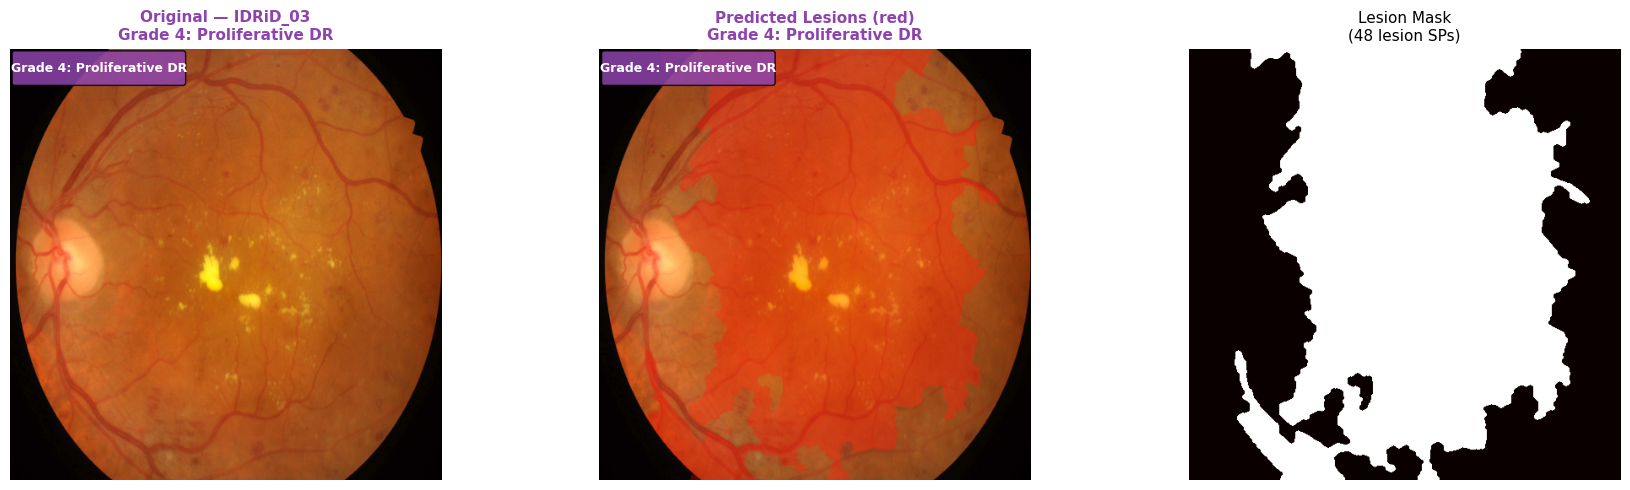

   IDRiD_03 | Grade 4: Proliferative DR | lesion SPs: 48


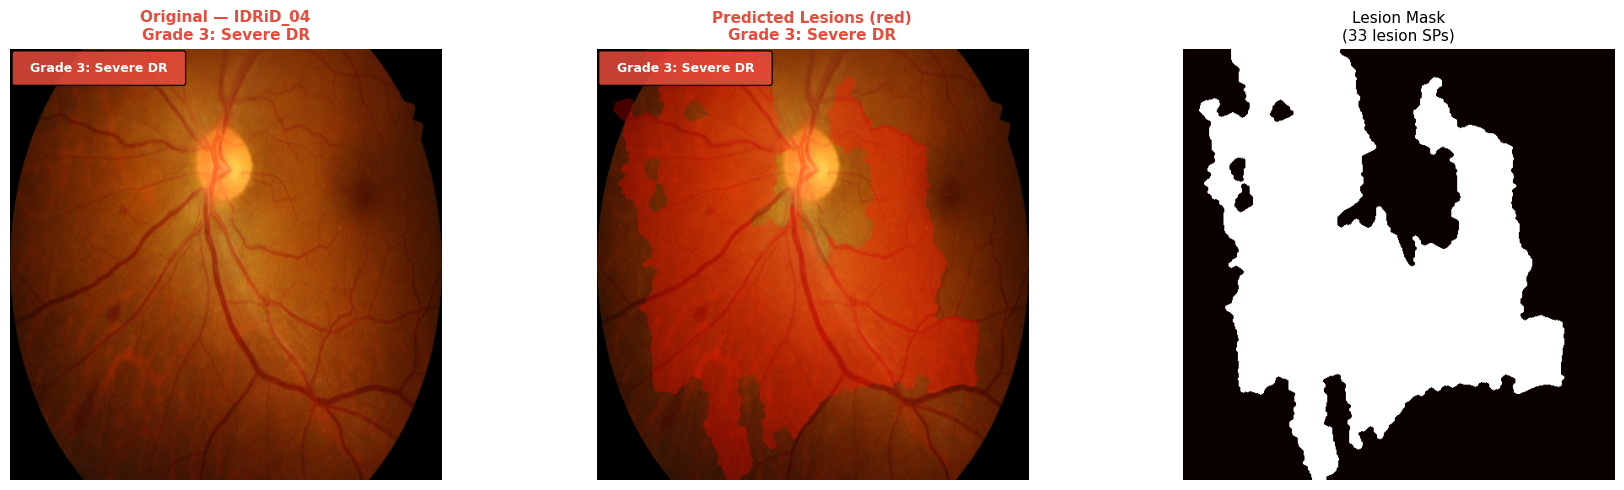

   IDRiD_04 | Grade 3: Severe DR | lesion SPs: 33


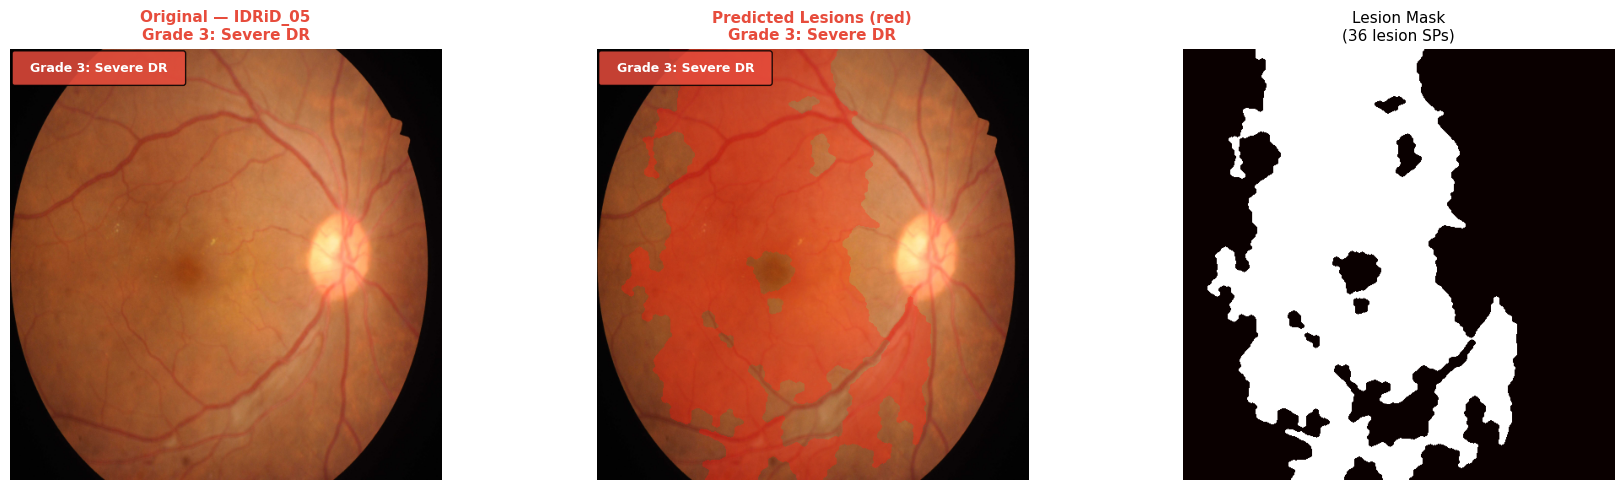

   IDRiD_05 | Grade 3: Severe DR | lesion SPs: 36


In [ ]:
# ── CELL: Run visualization with DR grade labels ─────────────

# First verify the grade lookup was built correctly
print("Grade lookup sample:")
for img_id, (gnum, gname) in list(idrid_grade_lookup.items())[:5]:
    print(f"  {img_id}: Grade {gnum} — {gname}")

print(f"\nTotal images in lookup: {len(idrid_grade_lookup)}")
print(f"Total evaluated results: {len(gt_all_results)}")
print()

# Now visualize
for res in gt_all_results[:5]:
    visualize_lesion_overlay(res, save=True, idrid_grade_lookup=idrid_grade_lookup)